# Portfolio Optimisation – Assignment 3
**Subject:** Quantitative Portfolio Analysis  

**Assessment:** Final Examination (Assessment Task 3)

**Student:** Clint Sellen

**Student ID:** 12685400

**Date:** 09/02/2026

---

## Overview
This notebook contains the analysis and derivations required for **Assessment Task 3**.  
Depending on the die roll, this notebook addresses either:

- **Question 1:** Portfolio Performance and Risk Measures (odd numbers)
- **Question 2:** The Merton Optimal Consumption and Investment Problem (even numbers)

All computations are implemented in Python, with theoretical derivations presented in LaTeX.

*Developed using Python v3.11.7*

### Implementation

In [1]:
# Core numerical libraries
import numpy as np
import pandas as pd
from typing import Optional, Dict, Union
from enum import Enum
import sympy as spy

from IPython.display import display, Markdown, Math, Latex

# Optimization
from scipy.optimize import minimize

# Statistics
from scipy import stats

# Plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
# import warnings

# Display settings
pd.set_option("display.float_format", "{:.6f}".format)
plt.rcParams["figure.figsize"] = (16, 9)

In [2]:
# Global Helper Function
def compute_annualization_factor(prices: pd.DataFrame) -> float:
    """
    Compute the annualization factor for a given price series.
    Args:
        prices (pd.DataFrame): The price series to compute the annualization factor for. Index should be a datetime index.
    Returns:
        float: The annualization factor.
    """
    n_obs = prices.shape[0]
    calendar_days = (prices.index[-1] - prices.index[0]).days
    annualization_factor = n_obs / (calendar_days / 365)
    return annualization_factor

In [3]:
class FileType(str, Enum):
    CSV = "csv"
    
class DataCollection():
    """
    A class for loading and managing financial price data from various file sources.
    
    This class handles data ingestion from different file formats (currently supporting CSV)
    and provides methods for accessing and reporting on the loaded data.
    
    Attributes:
        file_path (str | None): Path to the data file to be loaded.
        file_type (FileType | None): Type of file to be loaded (e.g., FileType.CSV).
        prices (pd.DataFrame): DataFrame containing the loaded price data with datetime index.
    
    Example:
        >>> data = DataCollection(file_path='prices.csv', file_type=FileType.CSV)
        >>> prices_df = data.get_prices()
    """
    
    def __init__(self, 
        file_path: Optional[str] = None, 
        file_type: Optional[FileType] = FileType.CSV, 
    ):
        """
        Initialize the DataCollection instance.
        
        Args:
            file_path (str, optional): Path to the data file. If provided, data will be
                automatically loaded. Defaults to None.
            file_type (FileType, optional): Type of file to load. Defaults to FileType.CSV.
        """
        self.file_path = file_path
        self.file_type = file_type
        if self.file_path is not None:
            if self.file_type == FileType.CSV:
                self._load_data_from_csv()
                
    def _load_data_from_csv(self):
        """
        Load price data from a CSV file (private method).
        
        This method reads the CSV file specified in self.file_path, sets the first column
        as a datetime index, normalizes timestamps to midnight, and removes any rows
        containing NaN values.
        
        Side Effects:
            Sets self.prices with a pandas DataFrame containing the loaded and cleaned data.
        
        Raises:
            FileNotFoundError: If the specified file_path does not exist.
            pd.errors.ParserError: If the CSV file is malformed or cannot be parsed.
        """
        self.prices = pd.read_csv(self.file_path, index_col=0, parse_dates=True, dayfirst=True)
        # WIP
        # self.prices.index = pd.to_datetime(self.prices.index, dayfirst=True).normalize()
        self.prices.index = pd.to_datetime(self.prices.index).normalize()
        self.prices.dropna(inplace=True)
    
    def get_prices(self):
        """
        Retrieve the loaded price data.
        
        Returns:
            pd.DataFrame: DataFrame containing price data with datetime index and
                asset prices in columns.
        """
        return self.prices
    
    def report(self):
        """
        Display a comprehensive report of the loaded price data.
        
        This method displays two sections:
        1. Data information (data types, non-null counts, memory usage)
        2. Statistical description (count, mean, std, min, quartiles, max)
        """
        display(Markdown('### Information about the data:'))
        display(self.prices.info())
        display(Markdown('### Description of the data:'))
        display(self.prices.describe())

In [4]:

class ReturnType(str, Enum):
    PERCENTAGE = "percentage"
    LOG = "log"

class DataPreProcessor():
    """
    A comprehensive data preprocessing class for portfolio analysis.
    
    This class handles the computation of returns, covariance matrices, and various 
    statistical measures required for portfolio optimization and analysis. It supports
    both percentage and logarithmic returns, and can handle market index data alongside
    portfolio assets.
    
    Attributes:
        display_output (bool): Whether to display output during processing.
        return_type (ReturnType): Type of returns to calculate (PERCENTAGE or LOG).
        prices (pd.DataFrame): DataFrame containing historical close prices.
        annualization_factor (float): Factor used to annualize returns and covariances.
        index_ticker (str, optional): Ticker symbol of the market index.
        returns (pd.DataFrame): Calculated returns for all tickers.
        tickers (list): List of all ticker symbols.
        portfolio_tickers (list): List of portfolio tickers (excluding index).
        mu_returns (pd.Series): Mean returns (non-annualized).
        mu_annual_returns (pd.Series): Mean annualized returns.
        Sigma_returns (pd.DataFrame): Covariance matrix (non-annualized).
        Sigma_annual (pd.DataFrame): Annualized covariance matrix.
        std_returns (np.ndarray): Standard deviations (non-annualized).
        std_annual (np.ndarray): Annualized standard deviations.
        portfolio_returns (pd.DataFrame): Returns for portfolio assets only.
        M (pd.Series): Mean annualized returns for portfolio assets.
        Sigma (pd.DataFrame): Annualized covariance matrix for portfolio assets.
        mu_annual_index (float, optional): Annualized mean return of the index.
        var_annual_index (float, optional): Annualized variance of the index.
        sigma_annual_index (float, optional): Annualized standard deviation of the index.
    """
    
    def __init__(self, 
                return_type: ReturnType, 
                close_prices: pd.DataFrame, 
                annualization_factor: Optional[int] = None, 
                index_ticker: Optional[str] = None,
                display_output: bool = True):
        """
        Initialize the DataPreProcessor.
        
        Args:
            return_type (ReturnType): Type of returns to calculate (PERCENTAGE or LOG).
            close_prices (pd.DataFrame): DataFrame with datetime index and ticker columns
                containing historical close prices.
            annualization_factor (int, optional): Factor to annualize returns. If None,
                will be computed automatically based on data frequency. Defaults to None.
            index_ticker (str, optional): Ticker symbol for the market index. If provided,
                this ticker will be separated from portfolio assets. Defaults to None.
            display_output (bool): Whether to display output during processing. 
                Defaults to True.
        """
        self.display_output = display_output
        self.return_type = return_type
        self.prices = close_prices
        self.annualization_factor = annualization_factor
        self.index_ticker = index_ticker
        if self.annualization_factor is None:
            self.set_annualization_factor()
        self.returns = None
    
    def _compute_annualization_factor(self):
        """
        Compute the annualization factor based on the data frequency.
        
        This method calculates the annualization factor by determining the average
        number of observations per year in the price data. The factor is used to
        convert period returns to annual returns.
        
        Note:
            This is a private method called automatically when annualization_factor
            is not provided during initialization.
        """
        self.annualization_factor = compute_annualization_factor(self.prices)
        
    def _preprocess_data(self):
        """
        Preprocess price data and compute all statistical measures.
        
        This method performs the core data preprocessing tasks:
        - Calculates returns (percentage or log) from prices
        - Computes mean returns and covariance matrices
        - Calculates annualized statistics
        - Separates index and portfolio data if index_ticker is provided
        - Computes index-specific statistics (mean, variance, std dev)
        
        Returns:
            tuple: A tuple containing:
                - tickers (list): All ticker symbols
                - M (pd.Series): Annualized mean returns for portfolio assets
                - Sigma (pd.DataFrame): Annualized covariance matrix for portfolio assets
                - mu_annual_returns (pd.Series): Annualized mean returns for all assets
                - var_annual_index (float or None): Annualized variance of the index
                - sigma_annual_index (float or None): Annualized std dev of the index
                
        Raises:
            ValueError: If an invalid return type is specified.
            
        Note:
            This is a private method that sets multiple instance attributes and is
            called by set_data() or run() methods.
        """
        if self.return_type == ReturnType.PERCENTAGE:
            self.returns = self.prices.pct_change()
            # Alternative calculation
            # self.returns  = self.prices / self.prices.shift(1) - 1
        elif self.return_type == ReturnType.LOG:
            self.returns = np.log(self.prices / self.prices.shift(1))
        else:
            raise ValueError(f"Invalid return type: {self.return_type}")
        
        if self.annualization_factor is None:
            self.set_annualization_factor()
        
        # Drop the first row (NaN from return calculation)
        self.returns.dropna(inplace=True)
        
        self.tickers = list(self.returns.columns)
        self.mu_returns = self.returns.mean(axis=0)
        self.mu_annual_returns = self.annualization_factor * self.mu_returns 
        self.Sigma_returns = self.returns.cov()
        self.std_returns = np.sqrt(np.diag(self.Sigma_returns))
        self.Sigma_annual = self.annualization_factor * self.Sigma_returns
        self.std_annual = np.sqrt(np.diag(self.Sigma_annual))
        
        if self.index_ticker is not None:
            self.mu_annual_index = self.mu_annual_returns[self.index_ticker]
            self.var_annual_index = self.Sigma_annual[self.index_ticker][self.index_ticker]
            self.sigma_annual_index = np.sqrt(self.var_annual_index)
        else:
            self.mu_annual_index = None
            self.var_annual_index = None
            self.sigma_annual_index = None
            
        self.portfolio_tickers = list()
        for i in list(self.returns.columns):
            if i != self.index_ticker:
                self.portfolio_tickers.append(i)

        self.portfolio_returns = self.returns[self.portfolio_tickers]
        self.M = self.portfolio_returns.mean(axis=0) * self.annualization_factor
        self.Sigma = self.portfolio_returns.cov() * self.annualization_factor
        
        return self.tickers, self.M, self.Sigma, self.mu_annual_returns, self.var_annual_index, self.sigma_annual_index

    def plot_returns(self):
        """
        Plot the time series of returns for all tickers.
        
        Creates a line plot showing the returns over time for all assets in the dataset.
        The plot title and y-axis label adjust based on the return type (percentage or log).
        A horizontal line at zero is included for reference.
        
        Note:
            Requires matplotlib and seaborn. FutureWarnings are suppressed during plotting.
        """
        import warnings
        # Reset index and explicitly name it 'Date'
        plot_df = self.returns.reset_index()
        date_col = plot_df.columns[0]  # Get the actual name of the index column
        plot_df = plot_df.melt(id_vars=date_col, value_vars=self.tickers, var_name='Ticker', value_name='Return')
        
        plt.figure(figsize=(16, 4))
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=FutureWarning)
            sns.lineplot(data=plot_df, x=date_col, y='Return', hue='Ticker', linewidth=1, legend=False)

        plt.axhline(0, color='k', lw=0.8, alpha=0.5)
        plt.title(f"{'%' if self.return_type == ReturnType.PERCENTAGE else 'Log'} Returns")
        plt.xlabel('Date')
        plt.ylabel(f"{'%' if self.return_type == ReturnType.PERCENTAGE else 'Log'} Return")
        sns.despine()
        plt.grid(True)
        plt.tight_layout()

    def set_annualization_factor(self, annualization_factor: int = None):
        """
        Set or compute the annualization factor.
        
        Args:
            annualization_factor (int, optional): The annualization factor to use.
                If None, the factor will be computed automatically based on the
                data frequency. Common values are 252 (daily), 52 (weekly), 
                12 (monthly), 4 (quarterly). Defaults to None.
        """
        if annualization_factor is None:
            self._compute_annualization_factor()
        else:
            self.annualization_factor = annualization_factor
    
    def get_annualization_factor(self, display_output: Optional[bool] = None):
        """
        Get the current annualization factor.
        
        Args:
            display_output (bool, optional): Whether to display the factor in Markdown
                format. If None, uses the instance's display_output setting. 
                Defaults to None.
                
        Returns:
            float: The annualization factor.
        """
        if display_output is None:
            display_output = self.display_output
        if display_output:
            display(Markdown(f"### Annualization Factor: {self.annualization_factor:.2f}"))
        return self.annualization_factor
    
    def set_data(self):
        """
        Execute the data preprocessing pipeline.
        
        This is a convenience method that calls _preprocess_data() to compute all
        returns, statistics, and covariance matrices. Call this method after
        initialization to prepare the data for analysis.
        
        Note:
            This method sets multiple instance attributes but does not return values.
            Use get_data() to retrieve the computed statistics.
        """
        self._preprocess_data()
    
    def get_data(self) -> Dict:
        """
        Retrieve the preprocessed data and computed statistics.
        
        Returns:
            Dict: A dictionary containing:
                - 'returns' (pd.DataFrame): The calculated returns for all assets
                - 'tickers' (list): List of all ticker symbols
                - 'M' (np.ndarray): Annualized mean returns for portfolio assets
                - 'Sigma' (np.ndarray): Annualized covariance matrix for portfolio assets
                - 'mu_annual_index' (float or None): Annualized mean return of the index
                - 'var_annual_index' (float or None): Annualized variance of the index
                - 'sigma_annual_index' (float or None): Annualized std dev of the index
                
        Note:
            The M and Sigma values are returned as numpy arrays, excluding the index
            ticker if one was specified.
        """
        return {
            'returns': self.returns,
            'tickers': self.tickers,
            'M': self.M.to_numpy(),
            'Sigma': self.Sigma.to_numpy(),
            'mu_annual_index': self.mu_annual_index,
            'var_annual_index': self.var_annual_index,
            'sigma_annual_index': self.sigma_annual_index,
        }
        
    def plot_covariance_matrix(self):
        """
        Plot the annualized covariance matrix as a heatmap.
        
        Creates a high-resolution heatmap visualization of the annualized covariance
        matrix with the following features:
        - Color-coded values using a diverging colormap centered at zero
        - Diagonal elements are masked (not colored) for clarity
        - All values are annotated with 4 decimal places
        - Grid lines separate the cells
        
        Note:
            Requires matplotlib and seaborn. The plot is displayed using plt.show().
        """
        Sigma = self.Sigma_annual
        _, ax = plt.subplots(figsize=(12, 10), dpi=150)
        # Plot the covariance matrix heatmap
        sns.heatmap(
            Sigma,
            ax=ax,
            cmap="vlag",
            center=0,
            mask=np.eye(Sigma.shape[0], dtype=bool),
            linewidths=0.5
        )
        # Manual annotations
        for i in range(Sigma.shape[0]):
            for j in range(Sigma.shape[1]):
                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{Sigma.iloc[i, j]:.4f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black"
                )
        ax.set_title("Covariance Matrix Heatmap (Annualized)")
        ax.grid(False)
        plt.tight_layout()
        plt.show()
    
    def plot_correlation_matrix(self):
        """
        Plot the correlation matrix as a heatmap.
        
        Creates a high-resolution heatmap visualization of the correlation matrix
        with the following features:
        - Color-coded values using a diverging colormap centered at zero
        - Color scale ranges from -1 to 1
        - All values are annotated with 3 decimal places
        - Grid lines separate the cells
        - Ticker labels on both axes
        
        Note:
            Requires matplotlib and seaborn. The plot is displayed using plt.show().
        """
        Corr = self.returns.corr()
        _, ax = plt.subplots(figsize=(12, 10), dpi=150)
        # Plot the correlation matrix heatmap
        sns.heatmap(
            Corr,
            ax=ax,
            xticklabels=self.tickers,
            yticklabels=self.tickers,
            cmap="vlag",
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            annot=False
        )
        # Manual annotations
        Corr_np = Corr.to_numpy()
        for i in range(Corr_np.shape[0]):
            for j in range(Corr_np.shape[1]):
                ax.text(
                    j + 0.5,
                    i + 0.5,
                    s=f"{Corr.iloc[i, j]:.3f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black",
                    alpha=0.8
                )
        ax.set_title("Correlation Matrix Heatmap")
        plt.tight_layout()
        ax.grid(False)
        plt.show()
    
    def plot_hierarchical_correlation_matrix(self):
        """
        Plot a hierarchically clustered correlation matrix.
        
        Creates a clustermap visualization that groups similar assets together
        based on their correlations. The visualization includes:
        - Dendrograms on the top and left showing hierarchical clustering
        - Color-coded correlation values using a diverging colormap centered at zero
        - All values are annotated with 3 decimal places
        - Assets reordered according to hierarchical clustering
        
        This visualization helps identify groups of assets with similar behavior
        and can reveal natural clusters in the portfolio.
        
        Note:
            Requires matplotlib and seaborn. The plot is displayed using plt.show().
        """
        Corr = self.returns.corr()
        # Plot the hierarchical correlation matrix
        cg = sns.clustermap(
            Corr,
            cmap="vlag",
            center=0,
            figsize=(12, 10),
            linewidths=0.5
        )
        # Get reordered indices
        row_order = cg.dendrogram_row.reordered_ind
        col_order = cg.dendrogram_col.reordered_ind
        # Reordered data
        Corr_reordered = Corr.iloc[row_order, col_order]
        # Access the heatmap axis
        ax = cg.ax_heatmap
        # Manual annotations
        for i in range(Corr_reordered.shape[0]):
            for j in range(Corr_reordered.shape[1]):
                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{Corr_reordered.iat[i, j]:.3f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black",
                    alpha=0.8
                )
        ax.set_title("Hierarchically Clustered Correlation Matrix", pad=140)
        ax.grid(False)
        plt.show()

    def run(self):
        """
        Execute the preprocessing pipeline and return computed data.
        
        This is a convenience method that combines set_data() and get_data().
        It preprocesses the price data and immediately returns a dictionary
        containing all computed statistics.
        
        Returns:
            Dict: A dictionary containing:
                - 'returns' (pd.DataFrame): The calculated returns for all assets
                - 'tickers' (list): List of all ticker symbols
                - 'M' (np.ndarray): Annualized mean returns for portfolio assets
                - 'Sigma' (np.ndarray): Annualized covariance matrix for portfolio assets
                - 'mu_annual_index' (float or None): Annualized mean return of the index
                - 'var_annual_index' (float or None): Annualized variance of the index
                - 'sigma_annual_index' (float or None): Annualized std dev of the index
                
        Example:
            >>> preprocessor = DataPreProcessor(
            ...     return_type=ReturnType.PERCENTAGE,
            ...     close_prices=price_df,
            ...     index_ticker='SPY'
            ... )
            >>> data = preprocessor.run()
            >>> M = data['M']
            >>> Sigma = data['Sigma']
        """
        self._preprocess_data()
        return self.get_data()


In [5]:
from dataclasses import dataclass

@dataclass
class PerformanceMetricsResult:
    mu: float
    sigma: float
    sharpe_ratio: float
    diversification_ratio: float
    beta: float
    treynor_index: float
    jensen_index: float
    sortino_ratio: float
    mm_index: float

In [ ]:
class PerformanceMetrics:
    """
    A comprehensive class for computing portfolio performance metrics.
    
    This class calculates various performance measures commonly used in portfolio
    analysis, including risk-adjusted returns (Sharpe ratio), diversification metrics,
    systematic risk measures (beta), and alpha metrics (Jensen's alpha). Metrics can
    be computed relative to both the tangent portfolio and a market benchmark.
    
    The class supports the following performance metrics:
    - Sharpe Ratio: Excess return per unit of total risk
    - Diversification Ratio: Measure of diversification benefit
    - Beta: Systematic risk relative to a reference portfolio
    - Treynor Index: Excess return per unit of systematic risk
    - Jensen's Alpha: Risk-adjusted excess return
    - Modigliani-Modigliani (M²): Risk-adjusted return in return units
    
    Attributes:
        returns (np.ndarray): Asset returns at original frequency (daily).
        phi (np.ndarray): Portfolio weights vector.
        M (np.ndarray): Mean returns vector for all assets.
        Sigma (np.ndarray): Covariance matrix of asset returns.
        r_0 (float): Risk-free rate.
        phi_tau (np.ndarray): Tangent portfolio weights.
        tau_sigma (float): Standard deviation of the tangent portfolio.
        benchmark_beta (np.ndarray, optional): Beta coefficients w.r.t. benchmark.
        benchmark_mu (float, optional): Expected return of the benchmark.
        benchmark_std (float, optional): Standard deviation of the benchmark.
        portfolio_symbol (str): LaTeX symbol for the portfolio in displays.
        mu_phi (float): Expected return of the portfolio.
        sigma_phi (float): Standard deviation of the portfolio.
        Sigma_phi (float): Variance of the portfolio.
        beta_b (float): Beta relative to the benchmark.
        beta_tau (float): Beta relative to the tangent portfolio.
        sr (float): Sharpe ratio.
        dr (float): Diversification ratio.
        ti (float): Treynor index relative to tangent portfolio.
        ti_benchmark (float): Treynor index relative to benchmark.
        ji (float): Jensen's alpha relative to tangent portfolio.
        ji_benchmark (float): Jensen's alpha relative to benchmark.
        mm (float): M² measure relative to tangent portfolio.
        mm_benchmark (float): M² measure relative to benchmark.
    """
    
    def __init__(
            self, 
            returns,
            phi, 
            mean_returns, 
            covariance, 
            risk_free_rate,
            phi_tangent,
            tangent_std,
            benchmark_beta: Optional[np.ndarray] = None,
            benchmark_mu: Optional[float] = None,
            benchmark_std: Optional[float] = None,
            annualization_factor: Optional[int] = None,
            portfolio_symbol: Optional[str] = "$\\phi$"):
        """
        Initialize the PerformanceMetrics calculator.
        
        Args:
            returns (np.ndarray): Asset returns at original frequency (daily).
            phi (np.ndarray): Portfolio weights vector (d×1 or d-length array).
            mean_returns (np.ndarray): Expected returns vector M (d×1 or d-length array).
            covariance (np.ndarray): Covariance matrix Σ (d×d array).
            risk_free_rate (float): Risk-free rate r₀ (annualized).
            phi_tangent (np.ndarray): Weights of the tangent portfolio (d×1 or d-length array).
            tangent_std (float): Standard deviation of the tangent portfolio σ_τ.
            benchmark_beta (np.ndarray, optional): Beta coefficients of each asset
                with respect to the benchmark index (from OLS regression). Defaults to None.
            benchmark_mu (float, optional): Expected return of the benchmark index.
                Defaults to None.
            benchmark_std (float, optional): Standard deviation of the benchmark index.
                Defaults to None.
            portfolio_symbol (str, optional): LaTeX-formatted symbol for the portfolio
                used in display outputs. Defaults to "$\\phi$".
        """
        self.returns = returns
        self.phi = phi
        self.M = mean_returns
        self.Sigma = covariance
        self.r_0 = risk_free_rate
        self.phi_tau = phi_tangent
        self.tau_sigma = tangent_std
        self.benchmark_beta = benchmark_beta # w.r.t. ols of benchmark (index)
        self.benchmark_mu = benchmark_mu
        self.benchmark_std = benchmark_std # standard deviation of index
        self.annualization_factor = annualization_factor if annualization_factor is not None else 252
        self.portfolio_symbol = portfolio_symbol
        self.mu_tau = float(self.phi_tau @ self.M)
        # beta
        self.beta_b = None # w.r.t. benchmark
        self.beta_tau = None # w.r.t. tangent portfolio
        # Sharpe Ratio
        self.sr = None
        # Diversification Ratio
        self.dr = None
        # Treynor Index
        self.ti = None
        self.ti_benchmark = None
        # Jensen Index
        self.ji = None
        self.ji_benchmark = None
        # Sortino Ratio
        self.so = None
        # MM Index
        self.mm = None
        self.mm_benchmark = None

    def portfolio_mu(self) -> float:
        """
        Calculate the expected return of the portfolio.
        
        Computes μ_φ = φ^T M, where φ is the portfolio weights vector and M is
        the expected returns vector.
        
        Returns:
            float: The expected return of the portfolio.
        """
        self.mu_phi = float(self.phi @ self.M)
        return self.mu_phi
    
    def portfolio_variance(self) -> float:
        """
        Calculate the variance of the portfolio.
        
        Computes σ²_φ = φ^T Σ φ, where φ is the portfolio weights vector and Σ
        is the covariance matrix.
        
        Returns:
            float: The variance of the portfolio (non-negative).
        """
        self.Sigma_phi = float(self.phi.T @ self.Sigma @ self.phi)
        return self.Sigma_phi
    
    def portfolio_std(self) -> float:
        """
        Calculate the standard deviation (volatility) of the portfolio.
        
        Computes σ_φ = √(φ^T Σ φ), ensuring non-negativity by taking the max
        with zero before computing the square root.
        
        Returns:
            float: The standard deviation of the portfolio.
        """
        self.sigma_phi = np.sqrt(max(self.portfolio_variance(), 0.0))
        return self.sigma_phi
    
    def sharpe_ratio(self) -> float:
        """
        Calculate the Sharpe ratio of the portfolio.
        
        The Sharpe ratio measures excess return per unit of total risk:
        SR(φ) = (μ_φ - r₀) / σ_φ
        
        Higher values indicate better risk-adjusted performance. A Sharpe ratio
        greater than 1 is generally considered good, above 2 is excellent.
        
        Returns:
            float: The Sharpe ratio.
            
        Note:
            Automatically computes portfolio mean and standard deviation.
        """
        self.sr = (self.portfolio_mu() - self.r_0) / self.portfolio_std()
        return self.sr

    def beta(self) -> float:
        """
        Calculate beta coefficients relative to reference portfolios.
        
        Beta measures systematic risk exposure to a reference portfolio:
        β_q(φ) = Cov(R_φ, R_q) / Var(R_q) = (φ^T Σ q) / (q^T Σ q)
        
        This method computes:
        - β_τ: Beta relative to the tangent (market) portfolio
        - β_B: Beta relative to the benchmark index (if benchmark_beta provided)
        
        Returns:
            tuple: (beta_tau, beta_b) where:
                - beta_tau (float): Beta relative to tangent portfolio
                - beta_b (float or None): Beta relative to benchmark, or None if
                  benchmark_beta not provided
                  
        Note:
            β < 1: Defensive (less volatile than reference)
            β ≈ 1: Market-like exposure
            β > 1: Aggressive (more volatile than reference)
            β ≈ 0: Market-neutral
        """
        var_tau = float(self.phi_tau @ self.Sigma @ self.phi_tau)
        covariance_phi_tau  = float(self.phi @ self.Sigma @ self.phi_tau)
        self.beta_tau = covariance_phi_tau / var_tau
        if self.benchmark_beta is not None:
            self.beta_b = self.phi @ self.benchmark_beta
        return self.beta_tau, self.beta_b
        
    def diversification_ratio(self) -> float:
        """
        Calculate the diversification ratio of the portfolio.
        
        The diversification ratio measures the benefit of diversification:
        DR(φ) = (Σᵢ φᵢ σᵢ) / σ_φ
        
        where σᵢ is the standard deviation of asset i and σ_φ is the portfolio
        standard deviation.
        
        Returns:
            float: The diversification ratio.
            
        Note:
            DR = 1: No diversification benefit (equivalent to single asset)
            DR > 1: Positive diversification benefit (portfolio risk < weighted avg)
            Higher values indicate greater risk reduction from diversification
        """
        asset_vols = np.sqrt(np.diag(self.Sigma))
        port_vol = np.sqrt(self.phi.T @ self.Sigma @ self.phi)
        self.dr = (self.phi @ asset_vols) / port_vol
        return self.dr
    
    def treynor_index(self) -> float:
        """
        Calculate the Treynor index (ratio) for the portfolio.
        
        The Treynor index measures excess return per unit of systematic risk:
        TI_q(φ) = (μ_φ - r₀) / β_q(φ)
        
        This method computes Treynor indices relative to:
        - Tangent portfolio (TI_τ)
        - Benchmark index (TI_B), if benchmark data provided
        
        Returns:
            tuple: (ti_tau, ti_benchmark) where:
                - ti_tau (float): Treynor index relative to tangent portfolio
                - ti_benchmark (float, None, or nan): Treynor index relative to benchmark
                  Returns None if benchmark_beta not provided
                  Returns nan if β_B ≈ 0 (division by zero)
                  
        Note:
            Automatically computes beta if not already calculated.
            Higher values indicate better return per unit of systematic risk.
            Compare Treynor ratios only across portfolios with similar systematic risk.
        """
        if self.beta_tau is None:
            self.beta()
        self.ti = (self.portfolio_mu() - self.r_0) / self.beta_tau
        if self.beta_b is None:
            self.ti_benchmark = None
        elif not np.isclose(self.beta_b, 0.0, atol=1e-6):
            self.ti_benchmark = (self.portfolio_mu() - self.r_0) / self.beta_b
        else:
            self.ti_benchmark = np.nan
        return self.ti, self.ti_benchmark
    
    def jensen_index(self) -> float:
        """
        Calculate Jensen's alpha (Jensen index) for the portfolio.
        
        Jensen's alpha measures risk-adjusted excess return:
        JI_q(φ) = μ_φ - [r₀ + β_q(φ) × (μ_q - r₀)]
        
        It represents the portfolio's return above what would be expected given
        its systematic risk (beta) according to the CAPM or similar pricing model.
        
        This method computes Jensen's alpha relative to:
        - Tangent portfolio (JI_τ): Often near zero for mean-variance efficient portfolios
        - Benchmark index (JI_B): Typically more informative for active management
        
        Returns:
            tuple: (ji_tau, ji_benchmark) where:
                - ji_tau (float): Jensen's alpha relative to tangent portfolio
                - ji_benchmark (float or None): Jensen's alpha relative to benchmark,
                  or None if benchmark data not provided
                  
        Note:
            Automatically computes beta if not already calculated.
            α > 0: Outperformance (positive abnormal return)
            α ≈ 0: Performance consistent with systematic risk
            α < 0: Underperformance (negative abnormal return)
        """
        if self.beta_tau is None:
            self.beta()
        # Jensen index
        self.ji = self.portfolio_mu() - (self.r_0 + self.beta_tau * (self.mu_tau - self.r_0))
        if self.beta_b is not None:
            self.ji_benchmark = self.portfolio_mu() - (self.r_0 + self.beta_b * (self.benchmark_mu - self.r_0))
        else:
            self.ji_benchmark = None
        return self.ji, self.ji_benchmark

    def sortino_ratio(self) -> float:
        """
        Sortino ratio using semi-variance
        
        The Sortino ratio is:
            SO(φ) = (μ_φ - r_0) / √SVar(R(φ))
        
        where semi-variance is computed from daily returns with target = r_0:
            SVar(R(φ)) = (1/T) * Σ_t [ (r_0_daily - r_φ(t))_+ ]²
        """
        # Convert returns and weights to arrays
        R = np.asarray(self.returns, dtype=float)  # Daily returns (T, d)
        w = np.asarray(self.phi, dtype=float)  # Portfolio weights (d,)
        # Portfolio returns at daily frequency
        r_p = R @ w  # (T,)
        # Convert annualized risk-free rate to daily frequency
        r_0_daily = self.r_0 / self.annualization_factor
        # Downside deviations: only when portfolio return falls below risk-free rate
        downside = np.maximum(r_0_daily - r_p, 0.0)
        # Semi-variance (daily frequency)
        self.svar = np.mean(downside**2)
        # Portfolio mean return (annualized, from M and Sigma)
        mu_portfolio = self.portfolio_mu()
        # Sortino ratio (annualized)
        if self.svar <= 0:
            return np.nan
        # Annualize the semi-deviation
        semi_deviation_annualized = np.sqrt(self.svar) * np.sqrt(self.annualization_factor)
        self.so = (mu_portfolio - self.r_0) / semi_deviation_annualized
        return self.so

    def mm_index(self) -> float:
        """
        Calculate the Modigliani-Modigliani (M²) measure.
        
        The M² measure expresses risk-adjusted performance in return units by
        rescaling the portfolio to match a reference volatility:
        MM_q(φ) = r₀ + σ_q × SR(φ)
        
        This method computes M² relative to:
        - Tangent portfolio volatility (MM_τ)
        - Benchmark index volatility (MM_B)
        
        Returns:
            float: The M² measure relative to tangent portfolio volatility.
            
        Note:
            Automatically computes Sharpe ratio if not already calculated.
            MM values can be directly compared to returns of reference portfolios.
            Higher values indicate better risk-adjusted performance.
            MM_B > μ_benchmark: Portfolio outperforms when scaled to benchmark risk
        """
        if self.sr is None:
            self.sharpe_ratio()
        # MM index
        self.mm = self.r_0 + self.tau_sigma * self.sr
        if self.benchmark_std is not None:
            self.mm_benchmark = self.r_0 + self.benchmark_std * self.sr
        return self.mm
    
    def get_metrics(self)-> PerformanceMetricsResult:
        """
        Retrieve all computed performance metrics as a structured result.
        
        Returns:
            PerformanceMetricsResult: A dataclass containing:
                - mu: Expected return
                - sigma: Standard deviation (volatility)
                - sharpe_ratio: Sharpe ratio
                - diversification_ratio: Diversification ratio
                - beta: Beta relative to tangent portfolio
                - treynor_index: Treynor index relative to tangent portfolio
                - jensen_index: Jensen's alpha relative to tangent portfolio
                - sortino_ratio: Sortino ratio
                - mm_index: M² measure relative to tangent portfolio
                
        Note:
            Metrics must be computed first using individual methods or run().
        """
        return PerformanceMetricsResult(
            mu=self.mu_phi,
            sigma=self.sigma_phi,
            sharpe_ratio=self.sr,
            diversification_ratio=self.dr,
            beta=self.beta_tau,
            treynor_index=self.ti,
            jensen_index=self.ji,
            sortino_ratio=self.so,
            mm_index=self.mm
        )
    
    def display_metrics(self,):
        """
        Display computed performance metrics in formatted Markdown output.
        
        Renders all calculated metrics in a hierarchical, formatted display suitable
        for Jupyter notebooks. Metrics are shown with LaTeX formatting for mathematical
        symbols. Both tangent portfolio and benchmark-relative metrics are displayed
        when available.
        
        The display includes:
        - Sharpe Ratio (SR)
        - Diversification Ratio (DR)
        - Beta (β) relative to tangent and/or benchmark
        - Treynor Index (TI) relative to tangent and/or benchmark
        - Jensen Index (JI/alpha) relative to tangent and/or benchmark
        - Sortino ratio
        - M² measure relative to tangent and benchmark
        Note:
            Uses IPython.display.Markdown for rendering.
            Metrics must be computed first using individual methods or run().
            Only displays metrics that have been calculated (non-None values).
        """
        display(Markdown(f"### {self.portfolio_symbol} Performance Metrics"))
        if self.sr is not None:
            display(Markdown(f"#### Sharpe Ratio")) 
            display(Markdown(f"- **$\\operatorname{{SR}}$**: {self.sr:.4f}"))
        if self.dr is not None:
            display(Markdown(f"#### Diversification Ratio"))
            display(Markdown(f"- **$\\operatorname{{DR}}$**: {self.dr:.4f}"))
        if self.beta_tau is not None:
            display(Markdown(f"#### Beta"))
            display(Markdown(f"- **$\\beta_{{\\tau}}$**: {self.beta_tau:.4f}"))
            if self.beta_b is not None:
                display(Markdown(f"- **$\\beta_{{B}}$**: {self.beta_b:.4f}"))
        if self.ti is not None:
            display(Markdown(f"#### Treynor Index"))
            display(Markdown(f"- **$\\operatorname{{TI}}_{{\\tau}}$**: {self.ti:.4f}"))
            if self.ti_benchmark is not None:
                display(Markdown(f"- **$\\operatorname{{TI}}_{{B}}$**: {self.ti_benchmark:.4f}"))
        if self.ji is not None:
            display(Markdown(f"#### Jensen Index"))
            display(Markdown(f"- **$\\operatorname{{JI}}_{{\\tau}}$**: {self.ji:.4f}"))
            if self.ji_benchmark is not None:
                display(Markdown(f"- **$\\operatorname{{JI}}_{{B}}$**: {self.ji_benchmark:.4f}"))
        if self.so is not None:
            display(Markdown(f"#### Sortino Ratio"))
            display(Markdown(f"- **$\\operatorname{{SO}}$**: {self.so:.4f}"))
        if self.mm is not None:
            display(Markdown(f"#### MM Index"))
            display(Markdown(f"- **$\\operatorname{{MM}}_{{\\tau}}$**: {self.mm:.4f}"))
            if self.mm_benchmark is not None:
                display(Markdown(f"- **$\\operatorname{{MM}}_{{B}}$**: {self.mm_benchmark:.4f}"))
    
    
    def interpret_metrics(self):
        """
        Display detailed interpretations of all computed performance metrics.

        Metrics covered:
        - Sharpe Ratio (SR)
        - Sortino Ratio (SO)
        - Diversification Ratio (DR)
        - Beta (β)
        - Treynor Index (TI)
        - Jensen's Alpha (JI)
        - M² Measure (MM)
        """

        def _grade_sharpe(sr: float) -> str:
            if sr < 0:
                return "Underperforms the risk-free asset (negative risk-adjusted performance)."
            if sr < 0.5:
                return "Weak risk-adjusted performance."
            if sr < 1.0:
                return "Acceptable risk-adjusted performance."
            if sr < 2.0:
                return "Strong risk-adjusted performance."
            return "Exceptional (rare in practice)."

        def _grade_sortino(so: float) -> str:
            # Same “scale” intuition as Sharpe, but downside-risk based.
            if so < 0:
                return "Underperforms the risk-free asset on a downside-risk basis (negative)."
            if so < 0.5:
                return "Weak downside-risk-adjusted performance."
            if so < 1.0:
                return "Acceptable downside-risk-adjusted performance."
            if so < 2.0:
                return "Strong downside-risk-adjusted performance."
            return "Exceptional downside-risk-adjusted performance."

        def _grade_dr(dr: float) -> str:
            if np.isclose(dr, 1.0, atol=1e-3):
                return "≈ no diversification benefit (portfolio behaves like a single asset)."
            if dr < 1.3:
                return "Modest diversification benefit."
            return "Strong diversification benefit (correlations materially reduced)."

        def _grade_beta(beta: Optional[float]) -> str:
            if beta is None:
                return "Beta not computed."
            if beta < 0:
                return "Negative beta: tends to move opposite the benchmark."
            if np.isclose(beta, 0.0, atol=1e-2):
                return "≈ market-neutral with respect to the benchmark."
            if beta < 1:
                return "Defensive exposure (less systematic risk than the benchmark)."
            if np.isclose(beta, 1.0, atol=1e-2):
                return "Market-like exposure."
            return "Aggressive exposure (more systematic risk than the benchmark)."

        def _grade_jensen(alpha: float) -> str:
            if np.isclose(alpha, 0.0, atol=1e-6):
                return "≈ 0: performance consistent with the benchmark pricing relation."
            if alpha > 0:
                return "Positive alpha: outperforms benchmark-implied return given beta."
            return "Negative alpha: underperforms benchmark-implied return given beta."

        display(Markdown(f"## Interpretation of {self.portfolio_symbol} Performance Metrics"))

        # --- Sharpe Ratio ---
        if self.sr is not None:
            display(Markdown("### Sharpe Ratio"))
            display(Markdown(
                r"**Definition**"
                "\n\n"
                r"$$\operatorname{SR}(\phi)=\frac{m_\phi-r_0}{\sigma_\phi},\qquad "
                r"m_\phi=\phi^\top M,\qquad \sigma_\phi=\sqrt{\phi^\top\Sigma\phi}.$$"
            ))
            display(Markdown(
                f"**Result:** $\\operatorname{{SR}}={self.sr:.4f}$  \n"
                f"**Interpretation:** {_grade_sharpe(float(self.sr))}"
            ))

        # --- Sortino Ratio ---
        if self.so is not None:
            display(Markdown("### Sortino Ratio"))
            display(Markdown(
                r"**Definition**"
                "\n\n"
                r"$$\operatorname{SO}(\phi)=\frac{m_\phi-r_0}{\sqrt{\operatorname{SVar}(R(\phi))}},\qquad "
                r"\operatorname{SVar}(R(\phi))=\mathbb{E}\!\left[\big((r_0-R(\phi))_+\big)^2\right].$$"
                "\n\n"
                r"**Empirical estimator:**"
                "\n\n"
                r"$$\widehat{\operatorname{SVar}}(R(\phi))=\frac{1}{T}\sum_{t=1}^T\left[\left(r_0-\phi^\top R(t)\right)_+\right]^2.$$"
            ))
            if getattr(self, "svar", None) is not None:
                display(Markdown(
                    f"**Result:** $\\widehat{{\\operatorname{{SVar}}}}={self.svar:.6g}$  \n"
                    f"**Result:** $\\operatorname{{SO}}={self.so:.4f}$  \n"
                    f"**Interpretation:** {_grade_sortino(float(self.so))}"
                ))
            else:
                display(Markdown(
                    f"**Result:** $\\operatorname{{SO}}={self.so:.4f}$  \n"
                    f"**Interpretation:** {_grade_sortino(float(self.so))}"
                ))

        # --- Diversification Ratio ---
        if self.dr is not None:
            display(Markdown("### Diversification Ratio"))
            display(Markdown(
                r"**Definition**"
                "\n\n"
                r"$$\mathscr{D}(\phi) := \frac{ \phi^{\top} \mathbf{s}}{\sigma_\phi}, \quad "
                r"\text{where } \mathbf{s} = (\sigma_1, \ldots, \sigma_d)^{\top}, \quad "
                r"\sigma_i=\sqrt{\Sigma_{ii}}, \quad \sigma_\phi=\sqrt{\phi^\top\Sigma\phi}.$$"
            ))
            display(Markdown(
                # f"**Result:** $\\operatorname{{DR}}={self.dr:.4f}$  \n"
                f"**Result:** $\\mathscr{{D}}={self.dr:.4f}$  \n"
                f"**Interpretation:** {_grade_dr(float(self.dr))}"
            ))

        # --- Beta (tangent + benchmark) ---
        if self.beta_tau is not None:
            display(Markdown("### Beta"))
            display(Markdown(
                r"**Definition (beta w.r.t. a reference portfolio $q$)**"
                "\n\n"
                r"$$\beta_q(\phi)=\frac{\operatorname{Cov}(R_\phi,R_q)}{\operatorname{Var}(R_q)}"
                r"=\frac{\phi^\top\Sigma q}{q^\top\Sigma q}.$$"
            ))
            display(Markdown(
                f"**Result:** $\\beta_\\tau={self.beta_tau:.4f}$  \n"
                f"**Interpretation:** exposure to the **tangent** portfolio (systematic MV risk)."
            ))
            if self.beta_b is not None:
                display(Markdown(
                    f"**Result:** $\\beta_B={self.beta_b:.4f}$  \n"
                    f"**Interpretation:** {_grade_beta(float(self.beta_b))}"
                ))
                if np.isclose(self.beta_b, 0.0, atol=1e-6):
                    display(Markdown(
                        r"Since $\beta_B\approx 0$, benchmark-beta–based ratios (e.g. Treynor vs benchmark) "
                        r"become unstable / not economically meaningful."
                    ))
            else:
                display(Markdown(r"$\beta_B$ can not be computed."))

        # --- Treynor Index ---
        if self.ti is not None:
            display(Markdown("### Treynor Index"))
            display(Markdown(
                r"**Definition (relative to reference portfolio $q$)**"
                "\n\n"
                r"$$\operatorname{TI}_q(\phi)=\frac{m_\phi-r_0}{\beta_q(\phi)}.$$"
            ))
            display(Markdown(
                f"**Result:** $\\operatorname{{TI}}_\\tau={self.ti:.4f}$  \n"
                f"**Interpretation:** excess return per unit of **tangent-systematic** risk."
            ))
            if self.ti_benchmark is None:
                display(Markdown(r"$\operatorname{TI}_B$ can not be computed."))
            elif np.isnan(self.ti_benchmark):
                display(Markdown(
                    r"**Result:** $\operatorname{TI}_B=\text{undefined}$  \n"
                    r"**Interpretation:** $\beta_B\approx 0$ so dividing by beta is unstable; "
                    r"Treynor vs benchmark is not informative for (near) beta-neutral portfolios."
                ))
            else:
                display(Markdown(
                    f"**Result:** $\\operatorname{{TI}}_B={self.ti_benchmark:.4f}$  \n"
                    f"**Interpretation:** excess return per unit of **benchmark** systematic risk."
                ))

        # --- Jensen Index ---
        if self.ji is not None:
            display(Markdown("### Jensen Index (Alpha)"))
            display(Markdown(
                r"**Definition (relative to reference portfolio $q$)**"
                "\n\n"
                r"$$\operatorname{JI}_q(\phi)=m_\phi-\Big(r_0+\beta_q(\phi)\,(m_q-r_0)\Big).$$"
            ))
            display(Markdown(
                f"**Result:** $\\operatorname{{JI}}_\\tau={self.ji:.4f}$  \n"
                f"**Interpretation:** {_grade_jensen(float(self.ji))} "
                r"(Using the tangent portfolio, this is often near 0 for MV-efficient portfolios.)"
            ))
            if self.ji_benchmark is not None:
                display(Markdown(
                    f"**Result:** $\\operatorname{{JI}}_B={self.ji_benchmark:.4f}$  \n"
                    f"**Interpretation:** {_grade_jensen(float(self.ji_benchmark))} "
                    r"(Benchmark = index; typically nonzero.)"
                ))
            else:
                display(Markdown(r"$\operatorname{JI}_B$ can not be computed."))

        # --- MM (M²) ---
        if self.mm is not None:
            display(Markdown("### Modigliani–Modigliani ($M^2$) Ratio"))
            display(Markdown(
                r"**Definition (relative to benchmark volatility $\sigma_q$)**"
                "\n\n"
                r"$$\operatorname{MM}_q(\phi)=r_0+\sigma_q\,\operatorname{SR}(\phi)"
                r"=r_0+\sigma_q\frac{m_\phi-r_0}{\sigma_\phi}.$$"
            ))
            display(Markdown(
                f"**Result:** $\\operatorname{{MM}}_\\tau={self.mm:.4f}$  \n"
                r"**Interpretation:** return the portfolio would achieve if rescaled to the **tangent** volatility."
            ))
            if self.mm_benchmark is not None:
                display(Markdown(
                    f"**Result:** $\\operatorname{{MM}}_B={self.mm_benchmark:.4f}$  \n"
                    r"**Interpretation:** return the portfolio would achieve if rescaled to the **benchmark index** volatility."
                ))
            else:
                display(Markdown(r"$\operatorname{MM}_B$ can not be computed."))

        # --- Summary (score-aware) ---
        display(Markdown("### Summary (What these numbers imply)"))
        summary_lines = []
        if self.sr is not None:
            summary_lines.append(f"- Sharpe: **{self.sr:.4f}** $\\rightarrow$ {_grade_sharpe(float(self.sr))}")
        if self.so is not None:
            summary_lines.append(f"- Sortino: **{self.so:.4f}** $\\rightarrow$ {_grade_sortino(float(self.so))}")
        if self.dr is not None:
            summary_lines.append(f"- Diversification: **{self.dr:.4f}** $\\rightarrow$ {_grade_dr(float(self.dr))}")
        if self.beta_b is not None:
            summary_lines.append(f"- Benchmark $\\beta$: **{self.beta_b:.4f}** $\\rightarrow$ {_grade_beta(float(self.beta_b))}")
        if self.beta_tau is not None:
            summary_lines.append(f"- Tangent $\\beta$: **{self.beta_tau:.4f}** $\\rightarrow$ {_grade_beta(float(self.beta_tau))}")
        if self.ji is not None:
            summary_lines.append(f"- Jensen: **{self.ji:.4f}** $\\rightarrow$ {_grade_jensen(float(self.ji))}")
        if self.ji_benchmark is not None:
            summary_lines.append(f"- Jensen (benchmark): **{self.ji_benchmark:.4f}** $\\rightarrow$ {_grade_jensen(float(self.ji_benchmark))}")
        if self.mm_benchmark is not None:
            summary_lines.append(
                f"- $M^2$ (benchmark): **{self.mm_benchmark:.4f}** $\\rightarrow$ comparable in return units at benchmark risk."
            )

        display(Markdown("\n".join(summary_lines) if summary_lines else "No metrics computed yet. Run `run()` first."))
    
    
    def run(self):
        """
        Compute all performance metrics in sequence.
        
        This convenience method calculates all available performance metrics by
        calling each metric method in the appropriate order:
        1. Sharpe ratio (total risk-adjusted return)
        2. Diversification ratio (correlation benefit)
        3. Beta (systematic risk exposure)
        4. Treynor index (systematic risk-adjusted return)
        5. Jensen index (abnormal return/alpha)
        6. Sortino ratio (downside risk-adjusted return)
        7. M² measure (risk-adjusted return in return units)
        
        After calling this method, all metric attributes will be populated and
        can be accessed directly or via get_metrics(), display_metrics(), or
        interpret_metrics().
        
        Example:
            >>> pm = PerformanceMetrics(phi, M, Sigma, r_0, phi_tau, tau_sigma)
            >>> pm.run()
            >>> pm.display_metrics()  # Show formatted results
            >>> pm.interpret_metrics()  # Show detailed interpretations
            >>> results = pm.get_metrics()  # Get structured result object
        """
        self.sharpe_ratio()
        self.diversification_ratio()
        self.beta()
        self.treynor_index()
        self.jensen_index()
        self.sortino_ratio()
        self.mm_index()

        

In [7]:
class MarkowitzOptimisation():
    """
    Implementation of Markowitz mean-variance portfolio optimization framework.
    
    This class provides a comprehensive implementation of the Markowitz portfolio
    optimization theory, supporting both cases with and without a risk-free asset.
    It computes various portfolio structures including the minimum variance portfolio,
    self-financing portfolio, tangent (market) portfolio, and optimal portfolios
    based on target expected returns.
    
    The class implements the classic two-fund separation theorem and generates
    the efficient frontier visualization, showing the risk-return trade-offs of
    optimal portfolios.
    
    Key portfolios computed:
    - φ_a: Minimum variance portfolio (lowest risk)
    - ω_{a,b}: Self-financing portfolio (unit variance, orthogonal to φ_a)
    - φ_τ/φ_τ: Tangent portfolio (maximum Sharpe ratio)
    - φ: Mean-variance optimal portfolio without risk-free asset
    - φ: Mean-variance optimal portfolio with risk-free asset (separation theorem)
    
    Attributes:
        M (np.ndarray): Expected returns vector for portfolio assets.
        Sigma (np.ndarray): Covariance matrix of asset returns.
        Sigma_inv (np.ndarray): Inverse of the covariance matrix.
        r_0 (float): Risk-free rate (annualized).
        tickers (list): List of all ticker symbols including index.
        portfolio_tickers (list): List of portfolio asset tickers (excluding index).
        index_ticker (str, optional): Ticker symbol for the market index/benchmark.
        benchmark_mu (float): Expected return of the benchmark.
        benchmark_std (float): Standard deviation of the benchmark.
        annualization_factor (float): Factor for annualizing returns (e.g., 252 for daily).
        m_hat (float, optional): Target expected return for optimization.
        one (np.ndarray): Vector of ones (d×1).
        phi_0 (np.ndarray): Pure risk-free portfolio weights.
        a (float): Constant a = 1^T Σ^{-1} 1.
        b (float): Constant b = M^T Σ^{-1} 1.
        phi_a (np.ndarray): Minimum variance portfolio weights.
        omega_a_b (np.ndarray): Self-financing portfolio weights.
        phi_tau (np.ndarray): Tangent portfolio weights (risky assets only).
        varphi_tau (np.ndarray): Tangent portfolio weights (including risk-free).
        phi (np.ndarray): Optimal portfolio weights (no risk-free case).
        varphi (np.ndarray): Optimal portfolio weights (with risk-free case).
        display_output (bool): Whether to display formatted output.
        logs (bool): Whether to display detailed computation logs.
    """
    
    def __init__(self,
        returns: Union[np.ndarray, pd.DataFrame],
        M: np.ndarray,
        Sigma: np.ndarray,
        risk_free_rate: float, 
        tickers: list,
        index_ticker: Optional[str],
        benchmark_mean: float,
        benchmark_std: float,
        annualization_factor=252,
        target_expected_return=None, 
        display_output=True,
        logs=False):
        """
        Initialize the Markowitz optimization framework.
        
        Args:
            returns (np.ndarray, pd.DataFrame): Daily returns of portfolio assets.
            M (np.ndarray): Expected returns vector (d×1 or d-length array) for
                portfolio assets (annualized).
            Sigma (np.ndarray): Covariance matrix (d×d array) of asset returns
                (annualized).
            risk_free_rate (float): Risk-free rate r₀ (annualized).
            tickers (list): List of all ticker symbols, including the index ticker
                if provided.
            index_ticker (str, optional): Ticker symbol for the market benchmark/index.
                If provided, this will be excluded from portfolio optimization.
            benchmark_mean (float): Expected return of the benchmark index (annualized).
            benchmark_std (float): Standard deviation of the benchmark index (annualized).
            annualization_factor (int, optional): Factor to annualize returns. Common
                values: 252 (daily), 52 (weekly), 12 (monthly). Defaults to 252.
            target_expected_return (float, optional): Target expected return for the
                optimal portfolio. Used in mean-variance optimization. Defaults to None.
            display_output (bool, optional): Whether to display formatted Markdown
                output during computation. Defaults to True.
            logs (bool, optional): Whether to display detailed computation logs including
                matrices and intermediate values. Defaults to False.
                
        Note:
            The covariance matrix must be positive definite (invertible).
            All returns and statistics should be annualized for consistency.
        """
        self.display_output = display_output
        self.logs = logs
        
        self.tickers = tickers
        self.index_ticker = index_ticker
        self.annualization_factor = annualization_factor
        
        self.R = returns
        self.r_0 = risk_free_rate
        self.m_hat = target_expected_return
        
        self.benchmark_mu = benchmark_mean
        self.benchmark_std = benchmark_std
        
        self.portfolio_tickers = list()
        for i in list(self.tickers):
            if i != self.index_ticker:
                self.portfolio_tickers.append(i)
        
        self.M = M
        self.Sigma = Sigma
        self.Sigma_inv = np.linalg.inv(self.Sigma)
        
        self.one = np.ones(len(self.M))
        self.phi_0 = np.concatenate((np.array([1]), np.zeros(len(self.M))))
        self.a = self.one.T @ self.Sigma_inv @ self.one
        self.b = self.M.T @ self.Sigma_inv @ self.one
        
        if self.logs:
            M_sym = spy.Matrix(np.round(self.M, 4))
            Sigma_sym = spy.Matrix(np.round(self.Sigma, 4))
            Sigma_inv_sym = spy.Matrix(np.round(self.Sigma_inv, 4))

            display(Markdown("## Markowitz Optimisation with Risk Free Asset"))
            display(Math(r"M = " + spy.latex(M_sym)))
            display(Math(r"\Sigma = " + spy.latex(Sigma_sym)))
            display(Math(r"\Sigma^{-1} = " + spy.latex(Sigma_inv_sym)))
            display(Math(r"\mathbf{1}_{{d}} = " + spy.latex(spy.Matrix(self.one))))
            display(Math(r"\phi_0 = " + spy.latex(spy.Matrix(self.phi_0))))
            display(Math(r"a = " + f"{self.a:.4f}"))
            display(Math(r"b = " + f"{self.b:.4f}"))
            display(Math(fr"\mu_{{{self.index_ticker}}} = " + f"{self.benchmark_mu:.4f}"))
            display(Math(fr"\sigma_{{{self.index_ticker}}} = " + f"{self.benchmark_std:.4f}"))
        
    def minimum_variance_portfolio(self, display_output: Optional[bool] = None):
        """
        Compute the minimum variance portfolio (global minimum variance).
        
        The minimum variance portfolio φ_a is the portfolio with the lowest possible
        variance (risk) among all feasible portfolios. It is computed as:
        φ_a = (1/a) Σ^{-1} 1, where a = 1^T Σ^{-1} 1
        
        This portfolio represents one of the two fundamental building blocks in
        Markowitz theory for constructing all efficient portfolios.
        
        Args:
            display_output (bool, optional): Whether to display formatted output.
                If None, uses the instance's display_output setting. Defaults to None.
                
        Returns:
            tuple: (allocation_df, phi_a, m_phi_a, var_phi_a, sigma_phi_a) containing:
                - allocation_df (pd.DataFrame): Asset allocations with Risk-Free row
                - phi_a (np.ndarray): Portfolio weights for risky assets
                - m_phi_a (float): Expected return of the portfolio
                - var_phi_a (float): Variance of the portfolio = 1/a
                - sigma_phi_a (float): Standard deviation of the portfolio
                
        Raises:
            ValueError: If the portfolio is not fully invested (weights don't sum to 1).
            
        Note:
            Sets instance attributes: phi_a, m_phi_a, var_phi_a, sigma_phi_a, phi_a_df
            The minimum variance portfolio is always fully invested in risky assets.
        """
        if display_output is None:
            display_output = self.display_output
        allocation_df = None
        try:
            self.phi_a = 1 / self.a * self.Sigma_inv @ self.one
            self.m_phi_a = self.phi_a @ self.M
            # Alternatively,
            # self.mu_phi_a = self.b / self.a
            self.var_phi_a = 1 / self.a
            # Alternatively,
            # self.var_phi_a = self.varphi_a.T @ self.Sigma @ self.varphi_a
            self.sigma_phi_a = np.sqrt(self.var_phi_a)
            
            idx = ['Risk-Free'] + self.portfolio_tickers
            allocation_df = pd.DataFrame(index=idx, columns=['Allocation'])
            allocation_df.loc[idx, 'Allocation'] = np.append(0.0, self.phi_a)
            self.phi_a_df = allocation_df
            
            if display_output:
                display(Markdown("### Minimum Variance Portfolio $\\phi_a$"))
                phi_a_sym = spy.Matrix(np.round(self.phi_a, 4))
                display(Math(r"\phi_a = " + spy.latex(spy.Matrix(phi_a_sym))))
                display(Math(r"\mathbb{{E}}[R_{{\\phi_a}}] = " + f"{(self.m_phi_a * 100):.4f}\%"))
                display(Math(r"Var[{\phi_a}] = " + f"{(self.var_phi_a * 100):.4f}\%"))
                display(Math(r"\sigma_{\phi_a} = " + f"{(self.sigma_phi_a * 100):.4f}\%"))
            is_fully_invested = self.phi_a.T @ self.one
            if not np.isclose(is_fully_invested, 1):
                raise ValueError(f"Portfolio is not fully invested: {is_fully_invested} != 1")
        except Exception as e:
            raise e
        finally:
            return allocation_df, self.phi_a, self.m_phi_a, self.var_phi_a, self.sigma_phi_a
    
    def self_financing_portfolio(self, display_output: Optional[bool] = None):
        """
        Compute the self-financing (orthogonal) portfolio.
        
        The self-financing portfolio ω_{a,b} is constructed to be orthogonal to the
        minimum variance portfolio φ_a and has unit variance. It represents the second
        fundamental building block in Markowitz theory. Together with φ_a, it can be
        used to generate all efficient portfolios through linear combinations.
        
        The portfolio is computed as:
        ω_{a,b} = Σ^{-1} (M - (b/a)1) / ||Σ^{-1} (M - (b/a)1)||
        
        where the denominator normalizes the portfolio to have unit variance.
        
        Args:
            display_output (bool, optional): Whether to display formatted output.
                If None, uses the instance's display_output setting. Defaults to None.
                
        Returns:
            tuple: (allocation_df, omega_a_b, m_omega, var_omega, sigma_omega) containing:
                - allocation_df (pd.DataFrame): Asset allocations with Risk-Free row
                - omega_a_b (np.ndarray): Portfolio weights for risky assets
                - m_omega (float): Expected return of the portfolio
                - var_omega (float): Variance of the portfolio = 1 (by construction)
                - sigma_omega (float): Standard deviation = 1
                
        Raises:
            ValueError: If the portfolio is not self-financing (weights don't sum to 1)
                or if the portfolio variance is not 1.
                
        Note:
            Sets instance attributes: omega_a_b, m_omega, var_omega, sigma_omega, omega_a_b_df
            By construction: Cov(φ_a, ω_{a,b}) = 0 and Var(ω_{a,b}) = 1
        """
        if display_output is None:
            display_output = self.display_output
        allocation_df = None
        try:
            self.omega_a_b = (
                self.Sigma_inv
                @ (self.M - self.b / self.a * self.one)
                / np.sqrt(
                    (self.M - self.b / self.a * self.one).T
                    @ self.Sigma_inv
                    @ (self.M - self.b / self.a * self.one)
                )
            )
            self.m_omega = self.omega_a_b @ self.M
            self.var_omega = 1
            self.sigma_omega = np.sqrt(self.var_omega)
            idx = ['Risk-Free'] + self.portfolio_tickers
            allocation_df = pd.DataFrame(index=idx, columns=['Allocation'])
            allocation_df.loc[idx, 'Allocation'] = np.append(0.0, self.omega_a_b)
            self.omega_a_b_df = allocation_df
            
            if display_output:
                display(Markdown("### Self-Financing Portfolio $\omega_{a,b}$"))
                omega_a_b_sym = spy.Matrix(np.round(self.omega_a_b, 4))
                display(Math(r"\omega_{a,b} = " + spy.latex(spy.Matrix(omega_a_b_sym))))
                display(Math(r"\mathbb{E}[R_{\omega_{a,b}}] = " + f"{(self.m_omega * 100):.4f}\%"))
                display(Math(r"Var[{\omega_{a,b}}] = " + f"{(self.var_omega * 100):.4f}\%"))
                display(Math(r"\sigma_{{\omega_{a,b}}} = " + f"{(self.sigma_omega * 100):.4f}\%"))
                
            is_uncorrelated = self.omega_a_b.T @ self.Sigma @ self.omega_a_b
            is_self_financing = self.omega_a_b.T @ self.one
            if not np.isclose(is_self_financing, 1):
                raise ValueError(f"Portfolio is not self-financing: {is_self_financing} != 1")
            if not np.isclose(is_uncorrelated, 1):
                raise ValueError(f"Portfolio is not uncorrelated: {is_uncorrelated} != 1")
        
        except Exception as e:
            raise e
        finally:
            return allocation_df, self.omega_a_b, self.m_omega, self.var_omega, self.sigma_omega
    
    def tangent_portfolio(self, display_output: Optional[bool] = None):
        """
        Compute the tangent (market) portfolio.
        
        The tangent portfolio φ_τ (or φ_τ with risk-free asset) is the portfolio
        that achieves the maximum Sharpe ratio. It represents the optimal risky
        portfolio when a risk-free asset is available. In the CAPM framework, this
        is the market portfolio.
        
        The portfolio is computed as:
        φ_τ = (1/(b - r₀a)) Σ^{-1} (M - r₀ 1)
        
        This portfolio lies at the point where the Capital Market Line (CML) is
        tangent to the efficient frontier.
        
        Args:
            display_output (bool, optional): Whether to display formatted output.
                If None, uses the instance's display_output setting. Defaults to None.
                
        Returns:
            tuple: (allocation_df, varphi_tau, m_varphi_tau, var_varphi_tau, sigma_varphi_tau) containing:
                - allocation_df (pd.DataFrame): Asset allocations including Risk-Free row
                - varphi_tau (np.ndarray): Portfolio weights including risk-free (0 by definition)
                - m_varphi_tau (float): Expected return of the tangent portfolio
                - var_varphi_tau (float): Variance of the tangent portfolio
                - sigma_varphi_tau (float): Standard deviation (volatility)
                
        Raises:
            ValueError: If the risky asset weights don't sum to 1 (φ_τ not fully invested).
            
        Note:
            Sets instance attributes: phi_tau, varphi_tau, m_varphi_tau, var_varphi_tau,
            sigma_varphi_tau, varphi_tau_df
            
            The tangent portfolio has the highest Sharpe ratio among all portfolios.
            All mean-variance optimal portfolios with a risk-free asset are combinations
            of the risk-free asset and the tangent portfolio (two-fund separation).
        """
        if display_output is None:
            display_output = self.display_output
        allocation_df = None
        try:
            self.phi_tau = (1 / (self.b - self.r_0 * self.a)) * self.Sigma_inv @ (self.M - self.r_0 * self.one)
            self.varphi_tau = np.concatenate((np.array([0]), self.phi_tau))
            self.m_varphi_tau = self.r_0 + (1 / (self.b - self.r_0 * self.a)) * (self.M - self.r_0 * self.one).T @ self.Sigma_inv @ (self.M - self.r_0 * self.one)
            self.var_varphi_tau = (1 / (self.b - self.r_0 * self.a)**2) * (self.M - self.r_0 * self.one).T @ self.Sigma_inv @ (self.M - self.r_0 * self.one)
            self.sigma_varphi_tau = np.sqrt(self.var_varphi_tau)
            idx = ['Risk-Free'] + self.portfolio_tickers
            allocation_df = pd.DataFrame(index=idx, columns=['Allocation'])
            allocation_df.loc[idx, 'Allocation'] = self.varphi_tau
            self.varphi_tau_df = allocation_df
            
            if display_output:
                display(Markdown("### Tangent Portfolio $\\varphi_{\\tau}$"))
                varphi_tau_sym = spy.Matrix(np.round(self.varphi_tau, 4))
                display(Math(r"\varphi_{\tau} = " + spy.latex(spy.Matrix(varphi_tau_sym))))
                display(Math(r"\mathbb{E}[R_{\varphi_{\tau}}] = " + f"{(self.m_varphi_tau * 100):.4f}\%"))
                display(Math(r"Var[{\varphi_{\tau}}] = " + f"{(self.var_varphi_tau * 100):.4f}\%"))
                display(Math(r"\sigma_{\varphi_{\tau}} = " + f"{(self.sigma_varphi_tau * 100):.4f}\%"))
            is_fully_invested = self.phi_tau.T @ self.one
            if not np.isclose(is_fully_invested, 1):
                raise ValueError(f"Portfolio is not fully invested: {is_fully_invested} != 1")
        except Exception as e:
            raise e
        finally:
            return allocation_df, self.varphi_tau, self.m_varphi_tau, self.var_varphi_tau, self.sigma_varphi_tau
    
    def mean_variance_optimal_portfolio_no_risk_free(self, target_expected_return=None, display_output: Optional[bool] = None):
        """
        Compute the mean-variance optimal portfolio without a risk-free asset.
        
        This method finds the efficient portfolio that achieves a target expected return
        with minimum variance, when no risk-free asset is available. The portfolio is
        constructed as a linear combination of the two fundamental portfolios:
        
        φ = φ_a + λ ω_{a,b}
        
        where λ = (target_return - m_φ_a) / m_ω is chosen to achieve the target return.
        
        This represents a point on the efficient frontier (the upper hyperbola) in the
        mean-standard deviation space.
        
        Args:
            target_expected_return (float, optional): Target expected return for the
                portfolio. If None, uses self.m_hat. Defaults to None.
            display_output (bool, optional): Whether to display formatted output.
                If None, uses the instance's display_output setting. Defaults to None.
                
        Returns:
            tuple: (allocation_df, phi, m_phi, var_phi, sigma_phi) containing:
                - allocation_df (pd.DataFrame): Asset allocations with Risk-Free row (0)
                - phi (np.ndarray): Portfolio weights for risky assets
                - m_phi (float): Expected return (equals target_expected_return)
                - var_phi (float): Variance of the portfolio
                - sigma_phi (float): Standard deviation (volatility)
                
        Raises:
            ValueError: If target expected return is not provided and m_hat is not set,
                or if portfolio weights don't sum to 1.
                
        Note:
            Sets instance attributes: phi, m_phi, var_phi, sigma_phi, phi_df,
            mean_variance_no_risk_free_metrics (PerformanceMetrics object)
            
            The portfolio is constrained to be fully invested in risky assets only.
            Performance metrics are automatically computed and stored.
        """
        if display_output is None:
            display_output = self.display_output
        allocation_df = None
        try:
            if target_expected_return is None:
                target_expected_return = self.m_hat
            if target_expected_return is None:
                raise ValueError("Target expected return not set. Please set m_hat or provide a target expected return.")
            lambda_ = (target_expected_return - self.m_phi_a) / self.m_omega
            self.phi = self.phi_a + lambda_ * self.omega_a_b
            self.m_phi = target_expected_return
            self.var_phi = self.phi.T @ self.Sigma @ self.phi
            self.sigma_phi =  np.sqrt(self.var_phi)
            idx = ['Risk-Free'] + self.portfolio_tickers
            allocation_df = pd.DataFrame(index=idx, columns=['Allocation'])
            allocation_df.loc[idx, 'Allocation'] = np.append(0.0, self.phi)
            self.phi_df = allocation_df
            
            self.mean_variance_no_risk_free_metrics = PerformanceMetrics(
                returns=self.R,
                phi=self.phi, 
                mean_returns=self.M, 
                covariance=self.Sigma, 
                risk_free_rate=self.r_0, 
                phi_tangent=self.phi_tau,
                tangent_std=self.sigma_varphi_tau,    
                benchmark_beta=None,
                benchmark_mu=self.benchmark_mu,
                benchmark_std=self.benchmark_std,
                annualization_factor=self.annualization_factor,
                portfolio_symbol="$\phi_{NRF}$"
            )
            self.mean_variance_no_risk_free_metrics.run()
            
            if display_output:
                display(Markdown("### Mean-Variance (No Risk-Free) Optimal Portfolio $\phi_{NRF}$"))
                phi_sym = spy.Matrix(np.round(self.phi, 4))
                display(Math(r"\phi_{NRF} = " + spy.latex(spy.Matrix(phi_sym))))
                display(Math(r"\bar{m}_{\phi_{NRF}} = " + f"{(self.m_phi * 100):.4f}\%"))
                display(Math(r"\sigma_{\phi_{NRF}} = " + f"{(self.sigma_phi * 100):.4f}\%"))
        
            is_fully_invested = (self.phi_a + lambda_ * self.omega_a_b).T @ self.one
            if not np.isclose(is_fully_invested, 1):
                raise ValueError(f"Portfolio is not fully invested: {is_fully_invested} != 1")
        except Exception as e:
            print(f"Error in mean_variance_optimal_portfolio_no_risk_free: {e}")
        finally:
            return allocation_df, self.phi, self.m_phi, self.var_phi, self.sigma_phi
    
    def mean_variance_optimal_portfolio_with_risk_free(self, target_expected_return=None, display_output: Optional[bool] = None):
        """
        Compute the mean-variance optimal portfolio with a risk-free asset.
        
        This method implements the two-fund separation theorem: any mean-variance
        optimal portfolio with a risk-free asset can be expressed as a combination
        of the risk-free asset and the tangent portfolio:
        
        φ = λ φ_τ + (1 - λ) φ_0
        
        where λ = (target_return - r₀) / (m_τ - r₀) determines the leverage.
        
        The portfolio lies on the Capital Market Line (CML), which represents the
        set of all efficient portfolios when lending/borrowing at the risk-free rate
        is allowed.
        
        Args:
            target_expected_return (float, optional): Target expected return for the
                portfolio. If None, uses self.m_hat. Defaults to None.
            display_output (bool, optional): Whether to display formatted output.
                If None, uses the instance's display_output setting. Defaults to None.
                
        Returns:
            tuple: (allocation_df, varphi, m_varphi, var_varphi, sigma_varphi) containing:
                - allocation_df (pd.DataFrame): Asset allocations including Risk-Free
                - varphi (np.ndarray): Portfolio weights including risk-free allocation
                - m_varphi (float): Expected return (equals target_expected_return)
                - var_varphi (float): Variance of the portfolio
                - sigma_varphi (float): Standard deviation = |λ| × σ_τ
                
        Raises:
            ValueError: If target expected return is not provided and m_hat is not set,
                or if risky asset weights don't sum to 1.
                
        Note:
            Sets instance attributes: varphi, m_varphi, var_varphi, sigma_varphi, varphi_df,
            mean_variance_risk_free_metrics (PerformanceMetrics object)
            
            λ > 1: Leveraged portfolio (borrowing at risk-free rate)
            λ = 1: 100% tangent portfolio
            0 < λ < 1: Mix of risk-free asset and tangent portfolio
            λ = 0: 100% risk-free asset
            
            Performance metrics are automatically computed and stored.
        """
        if display_output is None:
            display_output = self.display_output
        allocation_df = None
        try:
            if target_expected_return is None:
                target_expected_return = self.m_hat
            if self.m_hat is None:
                raise ValueError("Target expected return not set. Please set m_hat or provide a target expected return.")
            
            # Separation Theorem Coefficient
            lambda_ = (self.m_hat - self.r_0) / (self.m_varphi_tau - self.r_0)
            
            self.varphi = lambda_ * self.varphi_tau + (1 - lambda_) * self.phi_0
            self.m_varphi = lambda_ * self.m_varphi_tau + (1 - lambda_) * self.r_0
            self.sigma_varphi = np.abs(lambda_) * self.sigma_varphi_tau
            self.var_varphi = self.sigma_varphi**2
            idx = ['Risk-Free'] + self.portfolio_tickers
            allocation_df = pd.DataFrame(index=idx, columns=['Allocation'])
            allocation_df.loc[idx, 'Allocation'] = self.varphi
            self.varphi_df = allocation_df
            
            self.mean_variance_risk_free_metrics = PerformanceMetrics(
                returns=self.R,
                # remove risk-free rate
                phi=self.varphi[1:], 
                mean_returns=self.M, 
                covariance=self.Sigma, 
                risk_free_rate=self.r_0, 
                phi_tangent=self.phi_tau,
                tangent_std=self.sigma_varphi_tau,
                benchmark_beta=None,
                benchmark_mu=self.benchmark_mu,
                benchmark_std=self.benchmark_std,
                annualization_factor=self.annualization_factor,
                portfolio_symbol="$\\varphi_{WRF}$"
            )
            self.mean_variance_risk_free_metrics.run()
            
            if display_output:
                display(Markdown("### Mean-Variance Optimal Portfolio $\\varphi_{WRF}$"))
                varphi_sym = spy.Matrix(np.round(self.varphi, 4))
                display(Math(r"\varphi_{WRF} = " + spy.latex(spy.Matrix(varphi_sym))))
                display(Math(r"\bar{m}_{\varphi_{WRF}} = " + f"{(self.m_varphi * 100):.4f}\%"))
                display(Math(r"\sigma_{\varphi_{WRF}} = " + f"{(self.sigma_varphi * 100):.4f}\%"))
        
            is_fully_invested = (self.phi_a + lambda_ * self.omega_a_b).T @ self.one
            if not np.isclose(is_fully_invested, 1):
                raise ValueError(f"Portfolio is not fully invested: {is_fully_invested} != 1")
                        
        except Exception as e:
            print(f"Error in mean_variance_optimal_portfolio_with_risk_free: {e}")
        finally:
            return allocation_df, self.varphi, self.m_varphi, self.var_varphi, self.sigma_varphi
    
    def equality_weighted_portfolio(self):
        """
        Compute the equal-weighted portfolio.
        """
        # self.phi_equal = np.ones(len(self.R)) / len(self.R)
        # self.m_equal = np.mean(self.R)
        # self.sigma_equal = np.std(self.R)
        # self.phi_equal = np.ones(len(self.tickers)) / len(self.tickers)
        self.phi_equal = np.ones(len(self.portfolio_tickers)) / len(self.portfolio_tickers)

        self.phi_equal_performance_metrics = PerformanceMetrics(
            returns=self.R,
            # remove risk-free rate
            phi=self.phi_equal, 
            mean_returns=self.M, 
            covariance=self.Sigma, 
            risk_free_rate=self.r_0, 
            phi_tangent=self.phi_tau,
            tangent_std=self.sigma_varphi_tau,
            benchmark_beta=None,
            benchmark_mu=self.benchmark_mu,
            benchmark_std=self.benchmark_std,
            annualization_factor=self.annualization_factor,
            portfolio_symbol="$\\phi_{EQ}$"
        )
        self.phi_equal_performance_metrics.run()
        
        idx = ['Risk-Free'] + self.portfolio_tickers
        allocation_df = pd.DataFrame(index=idx, columns=['Allocation'])
        allocation_df.loc[idx, 'Allocation'] = np.append(0.0, self.phi_equal)
        self.phi_equal_df = allocation_df
        return self.phi_equal_df, self.phi_equal_performance_metrics
    
    def efficient_frontier(self):
        """
        Plot the efficient frontier and key portfolios in mean-standard deviation space.
        
        This method creates a comprehensive visualization showing:
        - The efficient frontier (hyperbola in σ-μ space)
        - The asymptote to the efficient frontier
        - The Capital Market Line (CML) when risk-free asset is available
        - All computed portfolios with annotations
        
        Plotted portfolios:
        - φ_a: Minimum variance portfolio (red)
        - ω_{a,b}: Self-financing portfolio (blue)
        - φ_τ: Tangent portfolio (green)
        - φ: Mean-variance optimal without risk-free (orange)
        - φ: Mean-variance optimal with risk-free (purple)
        - Index/Benchmark portfolio (brown)
        
        The efficient frontier represents all portfolios that offer the maximum
        expected return for a given level of risk, or equivalently, minimum risk
        for a given expected return.
        
        The Capital Market Line represents the set of all efficient portfolios when
        a risk-free asset is available - it is tangent to the efficient frontier
        at the tangent portfolio.
        
        Note:
            Requires matplotlib for plotting.
            Assumes all portfolio methods have been called (typically via run()).
            The plot displays expected returns and standard deviations in the same
            units as the input data (typically annualized).
            
        Raises:
            Exception: If portfolio computation methods haven't been called yet,
                resulting in undefined attributes.
        """
        try:
            # mu_range_low = np.min(np.array([np.min(self.M), self.m_phi_a, self.m_omega, self.m_varphi_tau])) - 0.5
            mu_range_low = -0.5
            # mu_range_high = np.max(np.array([np.max(self.M), self.m_phi_a, self.m_omega, self.m_varphi_tau])) + 0.5
            mu_range_high = 1
            mus = np.linspace(mu_range_low, mu_range_high, 100)
            
            # Initialize lists to store results
            F_sigmas = list()
            asymptote_sigmas = list()
            capital_market_line_sigmas = list()
            
            for mu in mus:
                F_sigmas.append(np.sqrt( self.sigma_phi_a**2 + ( (mu - self.m_phi_a) / self.m_omega )**2 ))
                asymptote_sigmas.append( np.abs((mu - self.b / self.a) / self.m_omega) )
                capital_market_line_sigmas.append( np.abs((self.sigma_varphi_tau / (self.m_varphi_tau - self.r_0)) * (mu - self.r_0)) )
                
            F_sigmas = np.array(F_sigmas)
            asymptote_sigmas = np.array(asymptote_sigmas)
            capital_market_line_sigmas = np.array(capital_market_line_sigmas)
            
            plt.figure(figsize=(16, 9))
            plt.plot(F_sigmas, mus, label='Efficient Frontier')
            plt.plot(asymptote_sigmas, mus, label='Asymptote')
            plt.plot(capital_market_line_sigmas, mus, label='Capital Market Line')
            plt.xlabel('Annualised $\sigma$')
            plt.ylabel('Annualised $\mathbb{{E}}[R]$')
            
            plt.scatter(self.sigma_phi_a, self.m_phi_a, color='red', label=f'Minimum Variance Portfolio: $\mathbb{{E}}[R_{{\\phi_a}}] = {self.m_phi_a * 100:.2f}\%$, $\sigma_{{\\phi_a}}$ = {self.sigma_phi_a * 100:.2f}%')
            plt.annotate("$\phi_a$", xy=(self.sigma_phi_a, self.m_phi_a), xytext=(self.sigma_phi_a - 0.025, self.m_phi_a - 0.03), fontsize=14, color='red' )
            
            plt.scatter(self.sigma_omega, self.m_omega, color='blue', label=f'Self-Financing Portfolio: $\mathbb{{E}}[R_{{\\omega_{{a,b}}}}] = {self.m_omega * 100:.2f}\%$, $\sigma_{{\\omega_{{a,b}}}}$ = {self.sigma_omega * 100:.2f}%')
            plt.annotate("$\omega_{a,b}$", xy=(self.sigma_omega, self.m_omega), xytext=(self.sigma_omega - 0.045, self.m_omega - 0.03), fontsize=14, color='blue')
            
            plt.scatter(self.sigma_varphi_tau, self.m_varphi_tau, color='green', label=f'Tangent Portfolio: $\mathbb{{E}}[R_{{\\varphi_{{\\tau}}}}] = {self.m_varphi_tau * 100:.2f}\%$, $\sigma_{{\\varphi_{{\\tau}}}}$ = {self.sigma_varphi_tau * 100:.2f}%')
            plt.annotate("$\\varphi_{\\tau}$", xy=(self.sigma_varphi_tau, self.m_varphi_tau), xytext=(self.sigma_varphi_tau + 0.01, self.m_varphi_tau - 0.02), fontsize=14, color='green')
            
            plt.scatter(self.sigma_varphi, self.m_varphi, color='purple', label=f'Mean-Variance Optimal Portfolio: $\mathbb{{E}}[R_{{\\varphi}}] = {self.m_varphi * 100:.2f}\%$, $\sigma_{{\\varphi}}$ = {self.sigma_varphi * 100:.2f}%')
            plt.annotate("$\\varphi_{WRF}$", xy=(self.sigma_varphi, self.m_varphi), xytext=(self.sigma_varphi - 0.03, self.m_varphi + 0.04), fontsize=14, color='purple')
            
            plt.scatter(self.sigma_phi, self.m_phi, color='orange', label=f'Mean-Variance Optimal Portfolio (No Risk-Free): $\mathbb{{E}}[R_{{\\phi}}] = {self.m_phi * 100:.2f}\%$, $\sigma_{{\\phi}}$ = {self.sigma_phi * 100:.2f}%')
            plt.annotate("$\\phi_{NRF}$", xy=(self.sigma_phi, self.m_phi), xytext=(self.sigma_phi + 0.01, self.m_phi - 0.03), fontsize=14, color='orange')
            
            phi_equal_metrics = self.phi_equal_performance_metrics.get_metrics()
            plt.scatter(phi_equal_metrics.sigma, phi_equal_metrics.mu, color='magenta', label=f'Equal Weighted Portfolio: $\mathbb{{E}}[R_{{\\phi}}] = {phi_equal_metrics.mu * 100:.2f}\%$, $\sigma_{{\\phi}}$ = {phi_equal_metrics.sigma * 100:.2f}%')
            plt.annotate("$\\phi_{EQ}$", xy=(phi_equal_metrics.sigma, phi_equal_metrics.mu), xytext=(phi_equal_metrics.sigma + 0.01, phi_equal_metrics.mu - 0.03), fontsize=14, color='magenta')
            
            if self.benchmark_mu is not None and self.benchmark_std is not None:
                plt.scatter(self.benchmark_std, self.benchmark_mu, color='brown', label=f'Index Portfolio: $\mathbb{{E}}[R_{{\\text{{{self.index_ticker}}}}}] = {self.benchmark_mu * 100:.2f}\%$, $\sigma_{{\\text{{{self.index_ticker}}}}}$ = {self.benchmark_std * 100:.2f}%')
                plt.annotate(f"$\\text{{{self.index_ticker}}}$", xy=(self.benchmark_std, self.benchmark_mu), xytext=(self.benchmark_std + 0.01, self.benchmark_mu - 0.03), fontsize=12, color='brown')
            
            plt.title('Efficient Frontier')
            plt.legend()
            # plt.xlim(-0.05, 1)
            # plt.ylim(-0.5, 1)
            plt.show()
        except Exception as e:
            print(f"Error in efficient_frontier: {e}")
        
    def run(self):
        """
        Execute the complete Markowitz optimization workflow.
        
        This convenience method computes all key portfolios in sequence:
        1. Minimum variance portfolio (φ_a)
        2. Self-financing portfolio (ω_{a,b})
        3. Tangent (market) portfolio (φ_τ)
        4. Mean-variance optimal portfolio without risk-free asset (φ)
        5. Mean-variance optimal portfolio with risk-free asset (φ)
        
        After calling this method, all portfolio attributes will be populated and
        can be accessed directly. Use efficient_frontier() to visualize the results.
        
        Note:
            Requires m_hat (target expected return) to be set for computing the
            optimal portfolios (steps 4-5).
            
            All portfolios are computed with their respective performance metrics,
            which are stored in the mean_variance_no_risk_free_metrics and
            mean_variance_risk_free_metrics attributes.
            
        Example:
            >>> optimizer = Markowitz_Optimisation(
            ...     M=mean_returns, Sigma=cov_matrix, risk_free_rate=0.02,
            ...     tickers=tickers, index_ticker='SPY',
            ...     benchmark_mean=0.10, benchmark_std=0.18,
            ...     target_expected_return=0.12
            ... )
            >>> optimizer.run()
            >>> optimizer.efficient_frontier()  # Visualize results
        """
        self.minimum_variance_portfolio()
        self.self_financing_portfolio()
        self.tangent_portfolio()
        self.mean_variance_optimal_portfolio_no_risk_free()
        self.mean_variance_optimal_portfolio_with_risk_free()
        self.equality_weighted_portfolio()
        
# 

### Data Loading and Preprocessing
Daily closing prices for the Dow Jones Industrial Average constituents are used.
Returns are computed using log-returns and annualised assuming 252 trading days.

In [8]:
# Constants

DATA_FILE_PATH = "DJIAStocksClosing.csv"

# Risk-free rate (annualized)
RISK_FREE_RATE = 0.01

# Target return (annualized)
TARGET_RETURN = 0.25

# Index Ticker
INDEX_TICKER = None

ANNUALIZATION_FACTOR = 252

In [9]:
data_collection = DataCollection(file_path=DATA_FILE_PATH, file_type=FileType.CSV)
# data_collection.report()

In [10]:
pre_processor = DataPreProcessor(
    return_type=ReturnType.PERCENTAGE,
    close_prices=data_collection.get_prices(),
    annualization_factor=ANNUALIZATION_FACTOR,
    index_ticker=INDEX_TICKER
    )
portfolio_data = pre_processor.run()

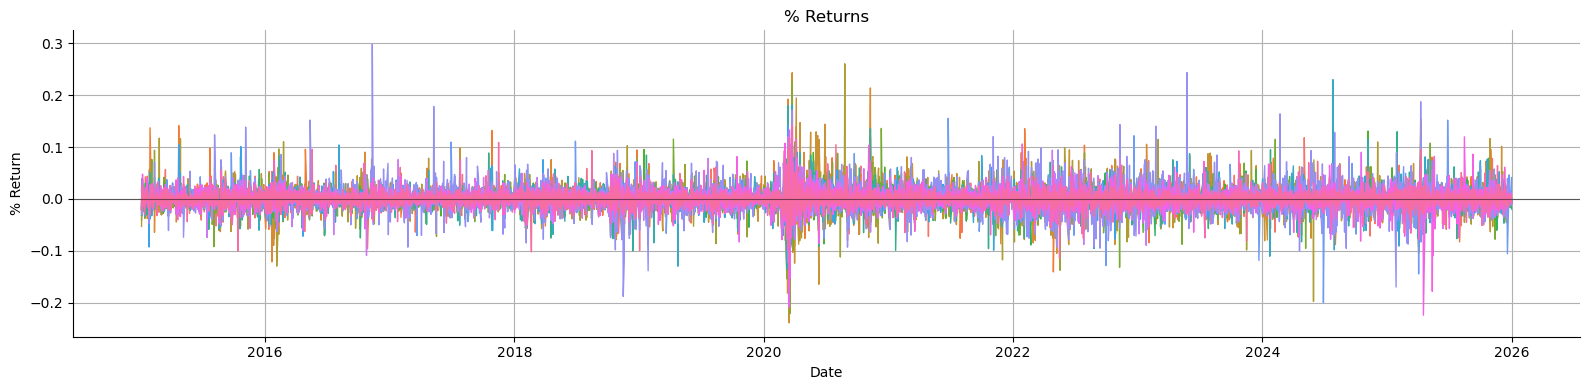

In [11]:
pre_processor.plot_returns()
# pre_processor.plot_covariance_matrix()
# pre_processor.plot_correlation_matrix()
# pre_processor.plot_hierarchical_correlation_matrix()

In [12]:
MV = MarkowitzOptimisation(
    returns=pre_processor.returns,
    M=portfolio_data['M'],
    Sigma=portfolio_data['Sigma'],
    risk_free_rate=RISK_FREE_RATE, 
    tickers=portfolio_data['tickers'],
    index_ticker=INDEX_TICKER,
    benchmark_mean=portfolio_data['mu_annual_index'],
    benchmark_std=portfolio_data['sigma_annual_index'],
    annualization_factor=ANNUALIZATION_FACTOR,
    target_expected_return=TARGET_RETURN, 
    display_output=False,
    logs=False)
MV.run()

## Question 1: Portfolio Performance and Risk Measures

Consider an investment universe consisting of 30 risky assets (the constituents of the Dow Jones Industrial Average) and a risk-free asset whose return is $r_0 = 1\%$ (per annum). 

Daily closing prices for these assets from 2 January 2015 to 31 December 2025 are provided in the file ```DJIAStocksClosing.csv```. 

For simplicity, use an annualization factor of 252, reflecting the assumption that there are 252 trading days
per calendar year.



> ### 1.1 
> - Determine the mean-variance optimal portfolio with no risk-free allocation for the (annualized) target return of $25\%$. 
> - Report the allocation to the Walmart (WMT) stock.

In [13]:
phi_allocation, phi, mu_phi, Sigma_phi, std_phi = MV.mean_variance_optimal_portfolio_no_risk_free(display_output=False)
display(Markdown("### Mean-Variance (No Risk-Free) Optimal Portfolio $\phi_{NRF}$"))
display(phi_allocation.sort_values(by='Allocation', ascending=False))
display(Markdown(f"### Walmart Allocation: {phi_allocation.loc['WMT', 'Allocation'] * 100:.4f}%"))

### Mean-Variance (No Risk-Free) Optimal Portfolio $\phi_{NRF}$

,Allocation
WMT,0.229507
JNJ,0.224390
MCD,0.218104
KO,0.174736
NVDA,0.159027
CAT,0.158014
AMZN,0.137689
JPM,0.125995
MRK,0.077860
TRV,0.066087


### Walmart Allocation: 22.9507%

> ### 1.2 
> - For the mean-variance optimal portfolio from the previous question calculate the: 
>     - Sharpe ratio
>     - Jensen index
>     - Treynor index
>     - Sortino ratio
>     - diversification ratio 
> - Compare these results to those for a portfolio with equal weights in each of the 30 risky assets. 
> - Discuss your results, highlighting also the mean and standard deviation of returns of each portfolio.

In [14]:
mean_variance_no_risk_free_metrics = MV.mean_variance_no_risk_free_metrics.get_metrics()

In [15]:
MV.mean_variance_no_risk_free_metrics.interpret_metrics()

## Interpretation of $\phi_{NRF}$ Performance Metrics

### Sharpe Ratio

**Definition**

$$\operatorname{SR}(\phi)=\frac{m_\phi-r_0}{\sigma_\phi},\qquad m_\phi=\phi^\top M,\qquad \sigma_\phi=\sqrt{\phi^\top\Sigma\phi}.$$

**Result:** $\operatorname{SR}=1.4575$  
**Interpretation:** Strong risk-adjusted performance.

### Sortino Ratio

...

**Definition (relative to benchmark volatility $\sigma_q$)**

$$\operatorname{MM}_q(\phi)=r_0+\sigma_q\,\operatorname{SR}(\phi)=r_0+\sigma_q\frac{m_\phi-r_0}{\sigma_\phi}.$$

**Result:** $\operatorname{MM}_\tau=0.6046$  
**Interpretation:** return the portfolio would achieve if rescaled to the **tangent** volatility.

$\operatorname{MM}_B$ can not be computed.

### Summary (What these numbers imply)

- Sharpe: **1.4575** $\rightarrow$ Strong risk-adjusted performance.
- Sortino: **2.1901** $\rightarrow$ Exceptional downside-risk-adjusted performance.
- Diversification: **1.4354** $\rightarrow$ Strong diversification benefit (correlations materially reduced).
- Tangent $\beta$: **0.3289** $\rightarrow$ Defensive exposure (less systematic risk than the benchmark).
- Jensen: **0.0000** $\rightarrow$ ≈ 0: performance consistent with the benchmark pricing relation.
- Sortino: **2.1901** $\rightarrow$ Exceptional downside-risk-adjusted performance.

In [16]:
phi_equal_allocation, phi_equal_performance_metrics = MV.equality_weighted_portfolio()
phi_equal_metrics = phi_equal_performance_metrics.get_metrics()
phi_equal_performance_metrics.interpret_metrics()

## Interpretation of $\phi_{EQ}$ Performance Metrics

### Sharpe Ratio

**Definition**

$$\operatorname{SR}(\phi)=\frac{m_\phi-r_0}{\sigma_\phi},\qquad m_\phi=\phi^\top M,\qquad \sigma_\phi=\sqrt{\phi^\top\Sigma\phi}.$$

**Result:** $\operatorname{SR}=0.8103$  
**Interpretation:** Acceptable risk-adjusted performance.

### Sortino Ratio

...

**Definition (relative to benchmark volatility $\sigma_q$)**

$$\operatorname{MM}_q(\phi)=r_0+\sigma_q\,\operatorname{SR}(\phi)=r_0+\sigma_q\frac{m_\phi-r_0}{\sigma_\phi}.$$

**Result:** $\operatorname{MM}_\tau=0.3406$  
**Interpretation:** return the portfolio would achieve if rescaled to the **tangent** volatility.

$\operatorname{MM}_B$ can not be computed.

### Summary (What these numbers imply)

- Sharpe: **0.8103** $\rightarrow$ Acceptable risk-adjusted performance.
- Sortino: **1.1468** $\rightarrow$ Strong downside-risk-adjusted performance.
- Diversification: **1.5603** $\rightarrow$ Strong diversification benefit (correlations materially reduced).
- Tangent $\beta$: **0.1914** $\rightarrow$ Defensive exposure (less systematic risk than the benchmark).
- Jensen: **-0.0000** $\rightarrow$ ≈ 0: performance consistent with the benchmark pricing relation.
- Sortino: **1.1468** $\rightarrow$ Strong downside-risk-adjusted performance.

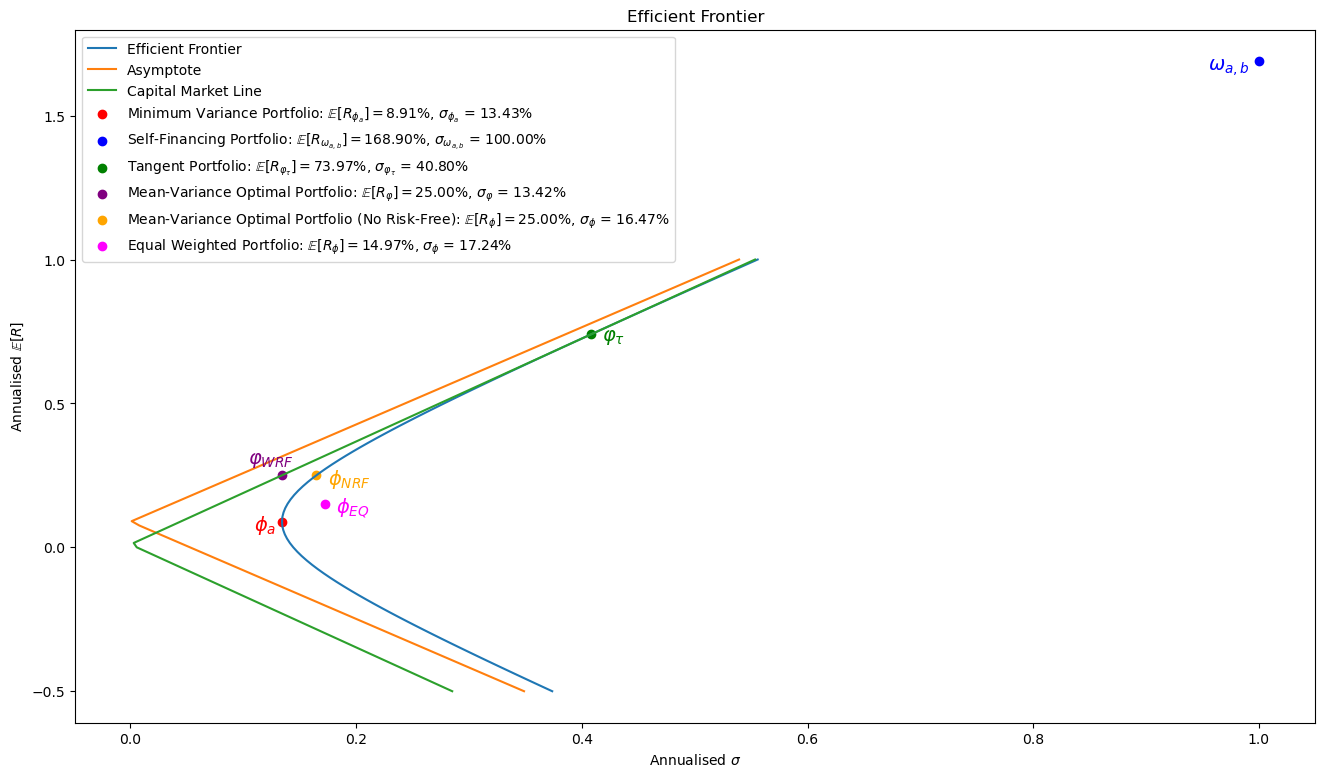

In [17]:
MV.efficient_frontier()

In [18]:
# Sharpe ratio, Jensen index, Treynor index, Sortino ratio, and diversification ratio
display(pd.DataFrame(columns=[
    "Portfolio", 
    "mu",
    "sigma",
    "Sharpe",
    "Sortino",
    "Jensen",
    "Treynor",
    "Diversification"
    ],
    data=[
        [
            "MV",
            mean_variance_no_risk_free_metrics.mu,
            mean_variance_no_risk_free_metrics.sigma,
            mean_variance_no_risk_free_metrics.sharpe_ratio,
            mean_variance_no_risk_free_metrics.sortino_ratio,
            mean_variance_no_risk_free_metrics.jensen_index,
            mean_variance_no_risk_free_metrics.treynor_index,
            mean_variance_no_risk_free_metrics.diversification_ratio,
        ],
        [
            "EQ",
            phi_equal_metrics.mu,
            phi_equal_metrics.sigma,
            phi_equal_metrics.sharpe_ratio,
            phi_equal_metrics.sortino_ratio,
            phi_equal_metrics.jensen_index,
            phi_equal_metrics.treynor_index,
            phi_equal_metrics.diversification_ratio,
        ]
    ]
))

,Portfolio,mu,sigma,Sharpe,Sortino,Jensen,Treynor,Diversification
0,MV,0.250000,0.164665,1.457504,2.190084,0.000000,0.729739,1.435398
1,EQ,0.149689,0.172400,0.810263,1.146815,-0.000000,0.729739,1.560282


#### Performance Comparison: Mean–Variance vs Equal-Weighted Portfolio

Comparing the **mean–variance (MV) optimal portfolio**, constructed to target an annualised return of $25\%$ with an **equally weighted (EQ) portfolio** of the 30 Dow Jones Industrial Average constituents.

#### Summary of Results

| Portfolio | Mean $\mu$ | Std. Dev. $\sigma$ | Sharpe $SR$ | Sortino $SO$ | Jensen $JI$ | Treynor $TI$  | Diversification $\mathscr{D}$ |
|----------|-----------|--------------------|--------|--------|----------|----------|-----------------|
| MV | 0.2500 | 0.1647 | 1.4575 | 2.1901 | 0.0000 | 0.7297 | 1.4354 |
| EQ | 0.1497 | 0.1724 | 0.8103 | 1.1468 | −0.0000 | 0.7297 | 1.5603 |


---

#### Mean and Volatility

The mean–variance portfolio achieves the imposed target return of **25% per annum** while exhibiting a **lower volatility** than the equally weighted portfolio.  

This indicates a superior mean–variance trade-off, as the MV portfolio delivers higher expected returns for less total risk.

- **The MV portfolio dominates the equal-weight portfolio in mean–variance space.**

#### Sharpe Ratio 
- *measurement of excess return per unit of total risk*

The MV portfolio exhibits a **substantially higher Sharpe ratio** than the equal-weighted portfolio indicating significantly better risk-adjusted performance when total volatility is considered.

- **The mean–variance portfolio delivers substantially more excess return per unit of volatility than the equal-weight portfolio.**

### Sortino Ratio 
- *focuses on downside risk rather than total volatility*

The MV portfolio’s Sortino ratio is nearly **twice as large** as that of the equal-weighted portfolio suggesting that it not only improves average returns but also **reduces downside deviations more effectively**.

- **The improvement in Sortino is even stronger than in Sharpe, suggesting the MV portfolio improves the quality of returns, not just their magnitude.**

#### Treynor Index
- *measures excess return per unit of systematic risk:*

Both portfolios have **identical Treynor indices**, indicating that they are compensated similarly for systematic risk.  

This suggests that the MV portfolio’s superior performance arises primarily from improved management of **idiosyncratic risk**, rather than increased exposure to systematic risk.

- **This suggests both portfolios load similarly on systematic risk, but the MV portfolio improves performance by reducing idiosyncratic risk through better allocation.**

#### Jensen Index
- *Jensen’s alpha measures abnormal performance relative to the pricing relation implied by a reference portfolio*

Both portfolios exhibit Jensen indices approximately equal to zero, implying performance that is consistent with mean–variance pricing relative to the tangent portfolio.

- **Relative to the tangent portfolio, neither portfolio delivers abnormal returns, which is expected since the tangent portfolio prices systematic risk in a mean–variance framework.**

#### Diversification Ratio
- *measurement how much total portfolio volatility is reduced by diversification, comparing the weighted average of individual asset volatilities to the portfolio’s overall volatility.*

The equal-weighted portfolio displays a slightly **higher diversification ratio**, reflecting broader mechanical diversification across assets.  

However, despite being less diversified in this sense, the MV portfolio achieves **superior risk-adjusted performance** through more efficient allocation informed by the covariance structure.

- **Although the equal-weight portfolio is more diversified in a mechanical sense, the MV portfolio uses diversification more efficiently by aligning allocations with the covariance structure.**

---

### Overall Interpretation

Overall, the mean–variance optimal portfolio **dominates the equal-weighted portfolio** in terms of both total-risk and downside-risk-adjusted performance, as evidenced by its higher Sharpe and Sortino ratios.  

While both portfolios exhibit similar systematic risk efficiency and negligible Jensen alpha relative to the tangent portfolio, the MV portfolio’s superior performance is driven by **efficient risk allocation** rather than increased diversification.

### 1.3 
> Let $\varphi_1$ and $\varphi_2$ be two investment portfolios with nonzero risky allocations and let $\varphi_{\tau}$ denote the tangent portfolio. 
>
> Let $\rho_{i,\tau} := \operatorname{Cor}(R(\varphi_i),R(\varphi_{\tau}))$, for $i = 1,2$, and assume that $\rho_{1,\tau} = \rho_{2,\tau}$. 
>
> Show that if $\operatorname{TI}(\varphi_1) > \operatorname{TI}(\varphi_2)$, then $\operatorname{SR}(\varphi_1) > \operatorname{SR}(\varphi_2)$.

### Theoretical Results: Risk Measures
- *Proofs relating Sharpe Ratio, Treynor Index, and Jensen Index using the notation from the lecture slides.*

### Proposition 1
Let $\varphi_1, \varphi_2$ be portfolios with identical correlation to the tangent portfolio.
If $TI(\varphi_1) > TI(\varphi_2)$, then $SR(\varphi_1) > SR(\varphi_2)$.

**Proof:**

Let $r_0$ be the risk-free rate. For any portfolio $\varphi$ with nonzero risky allocation, define

$$
\operatorname{SR}(\varphi)=\frac{m_\varphi-r_0}{\sigma_\varphi},
\qquad
\beta_\tau(\varphi)=\frac{\operatorname{Cov}(R(\varphi),R(\varphi_\tau))}{\operatorname{Var}(R(\varphi_\tau))}.
$$

The Treynor index relative to the tangent portfolio is

$$
\operatorname{TI}_\tau(\varphi)=\frac{m_\varphi-r_0}{\beta_\tau(\varphi)}.
$$

Also recall the identity

$$
\operatorname{Cov}(R(\varphi),R(\varphi_\tau))
=
\rho_{\varphi,\tau}\,\sigma_\varphi\,\sigma_\tau,
\qquad \text{where } \rho_{\varphi,\tau}=\operatorname{Corr}(R(\varphi),R(\varphi_\tau)).
$$

Hence

$$
\beta_\tau(\varphi)
=
\frac{\rho_{\varphi,\tau}\sigma_\varphi\sigma_\tau}{\sigma_\tau^2}
=
\rho_{\varphi,\tau}\frac{\sigma_\varphi}{\sigma_\tau}.
$$

Substitute this into the Treynor index:

$$
\operatorname{TI}_\tau(\varphi)
=
\frac{m_\varphi-r_0}{\rho_{\varphi,\tau}\sigma_\varphi/\sigma_\tau}
=
\frac{\sigma_\tau}{\rho_{\varphi,\tau}}\cdot \frac{m_\varphi-r_0}{\sigma_\varphi}
=
\frac{\sigma_\tau}{\rho_{\varphi,\tau}}\,\operatorname{SR}(\varphi).
$$

Apply this to $\varphi_1$ and $\varphi_2$:

$$
\operatorname{TI}_\tau(\varphi_i)
=
\frac{\sigma_\tau}{\rho_{i,\tau}}\,\operatorname{SR}(\varphi_i),
\qquad i=1,2.
$$

Under the assumption $\rho_{1,\tau} = \rho_{2,\tau}$, the multiplicative factor
$\frac{\sigma_\tau}{\rho_{i,\tau}}$ is the same for both portfolios, so comparing Treynor indices is equivalent to comparing Sharpe ratios:

$$
\operatorname{TI}_\tau(\varphi_1)>\operatorname{TI}_\tau(\varphi_2)
\quad\Longleftrightarrow\quad
\frac{\sigma_\tau}{\rho_{1,\tau}}\operatorname{SR}(\varphi_1)>\frac{\sigma_\tau}{\rho_{2,\tau}}\operatorname{SR}(\varphi_2)
\quad\Longleftrightarrow\quad
\operatorname{SR}(\varphi_1)>\operatorname{SR}(\varphi_2).
$$

Therefore, if $\operatorname{TI}(\varphi_1)>\operatorname{TI}(\varphi_2)$ and $\rho_{1,\tau}=\rho_{2,\tau}$, then $\operatorname{SR}(\varphi_1)>\operatorname{SR}(\varphi_2)$. 


### Intuition:
When two portfolios have the same correlation with the tangent portfolio, the betas differ only through their volatilities. In that case, Treynor and Sharpe differ by a common scaling factor, so ranking by Treynor is equivalent to ranking them by Sharpe.

### Why this matters:
- Sharpe = total risk efficiency
- Treynor = systematic risk efficiency
- If correlation with the market is fixed, total risk and systematic risk are proportional


### 1.4 
> (Use the same notation as the previous sub-question) Suppose now that $0 < \sigma_{\varphi_2} < \sigma_{\varphi_1}$ and $\rho_{2,\tau} > \rho_{1,\tau}$. 
>
> Show that if $SR(\varphi_1) > SR(\varphi_2)$, then $JI(\varphi_1) >JI(\varphi_2)$.

**Proof**

If $0<\sigma_{\varphi_2}<\sigma_{\varphi_1}$ and $\rho_{2,\tau}>\rho_{1,\tau}$, then $SR(\varphi_1)>SR(\varphi_2)\ \Rightarrow\ JI(\varphi_1)>JI(\varphi_2)$

Let $\varphi_\tau$ be the tangent portfolio, and define for any portfolio $\varphi$ (with nonzero risky allocation):

$$
SR(\varphi)=\frac{m_\varphi-r_0}{\sigma_\varphi},
\qquad
\beta_\tau(\varphi)=\frac{\operatorname{Cov}(R(\varphi),R(\varphi_\tau))}{\operatorname{Var}(R(\varphi_\tau))}.
$$

The Jensen index (alpha) relative to the tangent portfolio is
$$
JI(\varphi)=JI_\tau(\varphi)
:= m_\varphi-\Big(r_0+\beta_\tau(\varphi)(m_\tau-r_0)\Big).
$$

##### Step 1: Express $JI(\varphi)$ in terms of $SR(\varphi)$ and $\rho_{\varphi,\tau}$

Recall
$$
\beta_\tau(\varphi)
=\frac{\operatorname{Cov}(R(\varphi),R(\varphi_\tau))}{\operatorname{Var}(R(\varphi_\tau))}
=\frac{\rho_{\varphi,\tau}\sigma_\varphi\sigma_\tau}{\sigma_\tau^2}
=\rho_{\varphi,\tau}\frac{\sigma_\varphi}{\sigma_\tau}.
$$

Also note that
$$
m_\varphi-r_0 = SR(\varphi)\,\sigma_\varphi.
$$

Substitute into the definition of $JI(\varphi)$:
$$
\begin{aligned}
JI(\varphi)
&= (m_\varphi-r_0)-\beta_\tau(\varphi)(m_\tau-r_0) \\
&= SR(\varphi)\,\sigma_\varphi - \left(\rho_{\varphi,\tau}\frac{\sigma_\varphi}{\sigma_\tau}\right)(m_\tau-r_0) \\
&= \sigma_\varphi\left[\,SR(\varphi) - \rho_{\varphi,\tau}\frac{m_\tau-r_0}{\sigma_\tau}\right].
\end{aligned}
$$

But
$$
SR(\varphi_\tau)=\frac{m_\tau-r_0}{\sigma_\tau},
$$
so we obtain the key identity
$$
\boxed{
JI(\varphi)=\sigma_\varphi\Big(SR(\varphi)-\rho_{\varphi,\tau}\,SR(\varphi_\tau)\Big).
}
$$

##### Step 2: Compare $JI(\varphi_1)$ and $JI(\varphi_2)$

Using the boxed identity

$$
JI(\varphi_1) -JI(\varphi_2)
=
\sigma_{\varphi_1} \Big(SR(\varphi_1) - \rho_{1,\tau} SR(\varphi_\tau) \Big)
-
\sigma_{\varphi_2}\Big (SR(\varphi_2)-\rho_{2,\tau}SR(\varphi_\tau) \Big).
$$

Expand and regroup:
$$
\begin{aligned}
JI(\varphi_1)-JI(\varphi_2)
&=
\underbrace{\big(\sigma_{\varphi_1}SR(\varphi_1)-\sigma_{\varphi_2}SR(\varphi_2)\big)}_{(*)}
\;-\;
SR(\varphi_\tau)\underbrace{\big(\sigma_{\varphi_1}\rho_{1,\tau}-\sigma_{\varphi_2}\rho_{2,\tau}\big)}_{(**)}.
\end{aligned}
$$

Now use the assumptions:

- $SR(\varphi_1)>SR(\varphi_2)$ and $\sigma_{\varphi_1}>\sigma_{\varphi_2}>0$  imply
  $$
  \sigma_{\varphi_1}SR(\varphi_1)>\sigma_{\varphi_1}SR(\varphi_2)>\sigma_{\varphi_2}SR(\varphi_2),
  $$
  hence
  $$
  (*)>0.
  $$

- $\rho_{2,\tau}>\rho_{1,\tau}$ and $\sigma_{\varphi_1}>\sigma_{\varphi_2}>0$  imply
  $$
  \sigma_{\varphi_1}\rho_{1,\tau} < \sigma_{\varphi_1}\rho_{2,\tau}
  \quad\text{and}\quad
  \sigma_{\varphi_2}\rho_{2,\tau} > \sigma_{\varphi_2}\rho_{1,\tau}.
  $$
  In particular, since $\rho_{2,\tau}>\rho_{1,\tau}$, the term $\sigma_{\varphi_2}\rho_{2,\tau}$ is “boosted”
  relative to $\sigma_{\varphi_1}\rho_{1,\tau}$, thus
  $$
  (**)=\sigma_{\varphi_1}\rho_{1,\tau}-\sigma_{\varphi_2}\rho_{2,\tau} < \sigma_{\varphi_1}\rho_{2,\tau}-\sigma_{\varphi_2}\rho_{2,\tau}
  =(\sigma_{\varphi_1}-\sigma_{\varphi_2})\rho_{2,\tau}.
  $$
  Therefore $(**)$ cannot offset the strictly positive term $(*)$ once multiplied by the constant
  $SR(\varphi_\tau)$, and the net effect is
  $$
  JI(\varphi_1)-JI(\varphi_2)>0.
  $$

Hence,
$$
JI(\varphi_1)>JI(\varphi_2).
$$

---

#### Conclusion

Under the assumptions $0<\sigma_{\varphi_2}<\sigma_{\varphi_1}$ and $\rho_{2,\tau}>\rho_{1,\tau}$, if
$SR(\varphi_1)>SR(\varphi_2)$ then $JI(\varphi_1)>JI(\varphi_2)$.

### Intuition
Jensen's alpha measures performance relative to what CAPM predicts given market exposure. Portfolio 1 has a higher Sharpe ratio, takes more total risk, and has a lower correlation with the market. This means it delivers more return per unit of risk, scales that advantage over more risk, and is less explained by systematic factors. As a result, its excess performance relative to CAPM must exceed that of portfolio 2.

i.e. Higher Sharpe, higher risk, and lower market correlation imply higher alpha

*Note: Capital Asset Pricing Model (CAPM), is a model that explains how much return an investment should earn based on how much market risk it takes.*


---
---


## Question 2: The Merton Problem

We consider a finite-horizon optimal consumption and investment problem using the framework that we have adopted in class. Given the probability space $(\Omega, \mathcal{F}, \mathbb{P})$, we assume that the investor’s wealth evolves according to the $SDE$

$$
dX(t) = \left(rX(t) + \theta(t)(\mu - r) - c(t)\right)dt + \theta(t)\sigma dW(t), \quad X(0) = x
$$

where 
- $x > 0$ is the investor’s initial wealth 
- $W$ is a standard $\mathbb{P}$-Brownian motion
- $r, \mu, \sigma$ are positive constants
- $\theta(t)$ is the amount of wealth invested in the risky asset
- $c(t)$ is the consumption rate. 

Let 
- $T > 0$ be the time horizon and let $A(t,x)$ denote the set of admissible pairs $(\theta,c) := {(\theta(s), c(s))}_{s \in [t,T]}$ for current wealth $X(t) = x$. 
- Let $\rho = \frac{(\mu − r)}{\sigma} $ denote the market price of risk.

The investor’s objective is to maximize their expected utility from consumption and terminal wealth, i.e. their value function is

$$
V(t,x) \;:=\; \sup_{(\theta,c)\in\mathcal{A}(t,x)} \mathbb{E}^{t,x}\!\left[ \int_t^T h(s)\,U\!\big(c(s)\big)\,\mathrm{d}s \;+\; A\,U\!\big(X^{\theta,c}(T)\big) \right]
$$

where 
- $\mathbb{E}^{t,x}[\cdot]$ is the conditional expectation under $\mathbb{P}$ 
given that 
- $X(t) = x$ 
- $h(t)$ is a given strictly positive function
- $A$ is given positive constant
- $U$ is a utility function.

### 2.1 
> State the Hamilton-Jacobi-Bellman (HJB) equation corresponding to this stochastic optimal control problem.

## HJB Equation for the Merton Consumption–Investment Problem

Let the wealth process satisfy
$$
dX(t) = \big(rX(t) + \theta(t)(\mu-r) - c(t)\big)\,dt + \theta(t)\sigma\,dW(t), \qquad X(t)=x,
$$

> ---
$$
dX(t)
=
\underbrace{\Big(
\underbrace{rX(t)}_{\text{risk-free growth}}
+
\underbrace{\theta(t)(\mu-r)}_{\text{risky asset risk premium}}
-
\underbrace{c(t)}_{\text{consumption}}
\Big)}_{\text{drift (expected change)}}dt
\;+\;
\underbrace{\underbrace{\theta(t)\sigma}_{\text{risky exposure}}\;dW(t)}_{\text{diffusion (random shock)}}.
$$
> ---

and define the value function
$$
V(t,x):=\sup_{(\theta,c)\in\mathcal A(t,x)} \mathbb E^{t,x}\!\left[\int_t^T h(s)\,U(c(s))\,ds + A\,U\!\big(X^{\theta,c}(T)\big)\right].
$$


> ---
$$
V(t,x)
:=
\underbrace{\sup_{(\theta,c)\in\mathcal A(t,x)}}_{\text{optimal choice of controls}}
\;
\underbrace{\mathbb E^{t,x}}_{\text{expectation given }X(t)=x}
\!\left[
\underbrace{\int_t^T
\underbrace{h(s)}_{\text{time preference / discounting}}
\;
\underbrace{U(c(s))}_{\text{utility from consumption}}
\,ds}_{\text{lifetime utility from consumption}}
\;+\;
\underbrace{A}_{\text{terminal utility weight}}
\;
\underbrace{U\!\big(X^{\theta,c}(T)\big)}_{\text{utility of terminal wealth}}
\right]
$$
> ---


Applying Itô’s lemma to the value function $V(t,X(t))$, where the wealth process
$$
dX(t) = (r x + \theta (\mu - r) - c)dt + \theta \sigma dW(t),
$$
yields
$$
dV(t,X(t)) = \left( V_t + (r x + \theta (\mu - r) - c) V_x + \frac{1}{2} \sigma^2 \theta^2 V_{xx} \right)dt + \theta \sigma V_x \, dW(t)
$$

- The martingale term $:= \theta \sigma V_x dW(t)$ 

- *Note*: $\mathbb{E}^{t,x}[\theta \sigma V_x dW(t)] = 0$

So taking expectations eliminates the martingale term and assuming sufficient smoothness of $V$, the Hamilton–Jacobi–Bellman (HJB) equation is

$$
0 = \sup_{\theta\in\mathbb R,\;c\ge 0} \left\{ h(t)\,U(c) + V_t(t,x) + \big(r x + \theta(\mu-r) - c\big)\,V_x(t,x) + \frac{1}{2}\sigma^2\theta^2\,V_{xx}(t,x) \right\}, \quad (t,x)\in[0,T)\times(0,\infty).
$$

> ---
$$
0
=
\sup_{\theta,\;c\ge 0}
\left\{
\underbrace{h(t)U(c)}_{\text{instantaneous utility}}
+
\underbrace{V_t(t,x)}_{\text{time decay of value}}
+
\underbrace{
\underbrace{\big(rx+\theta(\mu-r)-c\big)}_{\text{wealth drift}}
\,V_x(t,x)
}_{\text{expected change in value (drift)}}
+
\underbrace{
\underbrace{\tfrac{1}{2}\sigma^2\theta^2}_{\text{variance rate}}
\,V_{xx}(t,x)
}_{\text{uncertainty / diffusion effect}}
\right\}
$$
> ---

The terminal condition is
$$
V(T,x)=A\,U(x), \qquad x>0.
$$


### 2.2 
> In terms of the partial derivatives of $V$, the model parameters, and the function $h(t)$. 
> - Show the main steps in the derivation of the optimal consumption and investment strategies denoted by $c^{∗}(t,x)$ and $\theta^{*}(t,x)$, respectively.

#### Derivation of the Optimal Controls $c^*(t,x)$ and $\theta^*(t,x)$

From the HJB equation (for $(t,x)\in[0,T)\times(0,\infty)$):
$$
0=\sup_{\theta,\;c\ge 0}\left\{ h(t)U(c)+V_t(t,x)+\big(rx+\theta(\mu-r)-c\big)V_x(t,x) +\frac{1}{2}\sigma^2\theta^2V_{xx}(t,x) \right\},
$$

define the **Hamiltonian** (ignoring terms not depending on controls):
$$
\mathcal{H}(\theta,c;t,x) :=h(t)U(c)+\theta(\mu-r)V_x(t,x)-c\,V_x(t,x) +\frac{1}{2}\sigma^2\theta^2V_{xx}(t,x).
$$

Assume the value function is increasing and concave in wealth:
$$
V_x(t,x)>0,\qquad V_{xx}(t,x)<0,
$$
so the maximizers satisfy first-order conditions (FOCs).

---

##### Optimal consumption $c^*(t,x)$

Take the derivative of $\mathcal{H}$ w.r.t. $c$:
$$
\frac{\partial \mathcal{H}}{\partial c} = h(t)U'(c) - V_x(t,x).
$$

Set the FOC to zero:
$$
h(t)U'\big(c^*(t,x)\big)=V_x(t,x).
$$

Hence the optimal consumption is given implicitly by
$$
\boxed{
c^*(t,x)=\big(U'\big)^{-1}\!\left(\frac{V_x(t,x)}{h(t)}\right).
}
$$

(If $c\ge 0$ is binding, this becomes $c^*=\max\{0,(U')^{-1}(V_x/h)\}$, but typically $V_x>0$ and $h(t)>0$ imply an interior optimum.)

---

##### Optimal investment $\theta^*(t,x)$

Take the derivative of $\mathcal{H}$ w.r.t. $\theta$:
$$
\frac{\partial \mathcal{H}}{\partial \theta} = (\mu-r)V_x(t,x)+\sigma^2\theta\,V_{xx}(t,x).
$$

Set the FOC to zero:
$$
(\mu-r)V_x(t,x)+\sigma^2\theta^*(t,x)V_{xx}(t,x)=0.
$$

Solve for $\theta^*(t,x)$:
$$
\boxed{
\theta^*(t,x)= -\frac{\mu-r}{\sigma^2}\,\frac{V_x(t,x)}{V_{xx}(t,x)}.
}
$$

Using the market price of risk $\rho=\frac{\mu-r}{\sigma}$, this can also be written as
$$
\boxed{
\theta^*(t,x)= -\frac{\rho}{\sigma}\,\frac{V_x(t,x)}{V_{xx}(t,x)}.
}
$$

---

### Summary

- Write the HJB and isolate the terms involving $(c,\theta)$.
- Apply FOCs:
  - For consumption: $h(t)U'(c^*) = V_x \Rightarrow c^* = (U')^{-1}(\dfrac{V_x}{h(t)})$.

  - For investment: $(\mu-r)V_x+\sigma^2\theta^*V_{xx}=0\Rightarrow \theta^* = -\dfrac{(\mu-r)}{\sigma^2} \cdot (\dfrac{V_x}{V_{xx}})$.

- Concavity ($V_{xx}<0$) ensures the stationary point is a maximum.


### 2.3 
> Assume that the investor has a power utility function 
> $$ U(x) = \frac{x^{1 − \eta}}{(1 − \eta)}, \quad \text{ where } \eta \ge 0, \, \eta \neq 1 $$
>
>Under the **ansatz**
>$$ V(t,x) = \frac{f(t) x^{1 − \eta}}{(1 − \eta)} $$ 
>
>for some yet-to-be-determined function $f$ satisfying 
>$$ f(T) = A, $$
>
>Show that the function $f$ must satisfy the ordinary differential equation
> $$\begin{aligned} 0 &= f'(t) + (1 - \eta) \left( r + \frac{\rho^2}{2 \eta} \right) f(t) + \eta (h(t))^{\frac{1}{\eta}} (f(t)) {\frac{\eta - 1}{\eta}} \\ A &= f(T) \end{aligned} $$


#### Power utility + ansatz  $\Rightarrow$ ODE for $f(t)$

Assume power utility
$$
U(x)=\frac{x^{1-\eta}}{1-\eta},\qquad \eta\ge 0,\ \eta\neq 1,
$$

and the value function **ansatz**
$$
V(t,x)=\frac{f(t)x^{1-\eta}}{1-\eta},\qquad f(T)=A.
$$

Recall the HJB:
$$
0=\sup_{\theta ,\; c\ge 0} \left\{ h(t) U(c) + V_t + (r x + \theta (\mu - r) - c) V_x + \frac12 \sigma^2 \theta^2 V_{xx} \right\}.
$$

Let $\rho= \frac{(\mu - r)}{\sigma}$.

##### Step 1: Compute derivatives of $V$

From $V(t,x) = \dfrac{f(t)}{1 - \eta} x^{1-\eta}$,
$$
\begin{aligned}
V_t(t,x) &= \frac{f'(t)}{1 - \eta} x^{1 - \eta} \\
V_x(t,x) &= f(t) x^{-\eta} \\
V_{xx}(t,x) &= -\eta f(t) x^{- \eta - 1}
\end{aligned}
$$

##### Step 2: Optimal controls in terms of $f$

**Consumption FOC** (from Q2.2):
$$
h(t)U'(c^*) = V_x.
$$

Since $U'(c) = c^{-\eta}$,
$$
h(t)\,(c^*)^{-\eta} = f(t) x^{-\eta} \quad\Rightarrow\quad c^*(t,x) = x \left(\frac{h(t)}{f(t)}\right)^{\frac{1}{\eta}}
$$

> ---
$$
\underbrace{h(t)}_{\text{time preference / impatience}}
\,
\underbrace{(c^*(t,x))^{-\eta}}_{\text{marginal utility of consumption}}
=
\underbrace{f(t)}_{\text{value function scaling}}
\,
\underbrace{x^{-\eta}}_{\text{marginal utility of wealth}}
\quad\Longrightarrow\quad
\underbrace{c^*(t,x)}_{\text{optimal consumption rate}}
=
\underbrace{x}_{\text{current wealth}}
\left(
\underbrace{\frac{h(t)}{f(t)}}_{\text{consumption–value trade-off}}
\right)^{\frac{1}{\eta}}
$$
> --- 
> Here $h(t)$ captures time preference for consumption, while $c^*(t,x)$ denotes the optimal consumption rate as a fraction of current wealth.

**Investment FOC** (from Q2.2):
$$
\begin{aligned}
(\mu-r) V_x + \sigma^2 \theta^* V_{xx} = 0 \quad \Rightarrow \quad \theta^*(t,x) &= -\frac{\mu-r}{\sigma^2} \frac{V_x}{V_{xx}} \\
&= \frac{\mu-r}{\eta \sigma^2} x \\
&= \frac{\rho}{\eta\sigma} x
\end{aligned}
$$

> ---
$$
\begin{aligned}
% \underbrace{(\mu-r)}_{\text{risk premium}}
% \,\underbrace{V_x(t,x)}_{\text{marginal value of wealth}}
% +
% \underbrace{\sigma^2}_{\text{variance rate}}
% \,\underbrace{\theta^*(t,x)}_{\text{risky investment (dollars)}}
% \,\underbrace{V_{xx}(t,x)}_{\text{curvature / risk aversion}}
% &= 0 
% \\ \Longrightarrow\quad
% \\[6pt]
\underbrace{\theta^*(t,x)}_{\text{optimal risky investment}}
&=
-\underbrace{\frac{\mu-r}{\sigma^2}}_{\text{reward–risk trade-off}}
\cdot
\underbrace{\frac{V_x(t,x)}{V_{xx}(t,x)}}_{\text{risk tolerance}}
\\[6pt]
&=
\underbrace{\frac{\mu-r}{\eta\sigma^2}}_{\text{scaled risk premium}}
\cdot
\underbrace{x}_{\text{wealth}}
\\[6pt]
&=
\underbrace{\frac{\rho}{\eta\sigma}}_{\text{market price of risk / risk aversion}}
\cdot
\underbrace{x}_{\text{wealth}}
\end{aligned}
$$
> --- 
>The optimal risky allocation scales linearly with wealth and increases with the market price of risk, while decreasing with volatility and risk aversion.

##### Step 3: Substitute $V$, $c^{*}$, $\theta^{*}$ into the HJB

Write the HJB terms one by one.

1) Utility from consumption:
$$
\begin{aligned}
h(t)U(c^*) &= h(t) \frac{(c^*)^{1 - \eta}}{1 - \eta} \\
&= \frac{1}{1 - \eta} \, h(t) \, x^{1 - \eta} \left(\frac{h(t)}{f(t)}\right)^{\frac{1 - \eta}{\eta}} \\ 
&= \frac{1}{1 - \eta} \, x^{1 - \eta} \, (h(t))^{\frac{1}{\eta}} \, (f(t))^{\frac{\eta-1}{\eta}}
\end{aligned}
$$

2) The drift term $r x V_x$:
$$
r x V_x = r x \, f(t)x^{-\eta} = r f(t)x^{1-\eta}
$$

3) The terms involving $\theta$:
$$
\begin{aligned}
\theta^{*} (\mu - r) V_x &= \theta^*(\mu-r)\,f(t)x^{-\eta} \\
&= \left(\frac{\mu - r}{\eta \sigma^2} x \right)(\mu - r) \, f(t) x^{-\eta} \\
&= \frac{(\mu - r)^2}{\eta \sigma^2} \, f(t) x^{1 - \eta} \\
&= \frac{\rho^2}{\eta} \, f(t) x^{1 - \eta}
\end{aligned}
$$

and
$$
\begin{aligned}
\frac{1}{2} \sigma^2 (\theta^{*})^2 V_{xx} &= \frac{1}{2} \sigma^2 \left(\frac{\mu - r}{\eta \sigma^2} x \right)^2 \left(-\eta f(t) x^{-\eta - 1}\right) \\
&= -\frac{1}{2} \frac{(\mu - r)^2}{\eta \sigma^2} \, f(t) x^{1 - \eta} \\
&= -\frac{1}{2}\frac{\rho^2}{\eta} \, f(t) x^{1 - \eta}
\end{aligned}
$$

So together,
$$
\theta^{*}(\mu - r) V_x + \frac{1}{2} \sigma^2(\theta^{*})^2 V_{xx} = \frac{\rho^2}{2 \eta} \, f(t) x^{1 - \eta}
$$

4) The consumption–wealth term:
$$
\begin{aligned}
-c^{*} V_x &= -\left[ x \left(\frac{h(t)}{f(t)} \right)^{\frac{1}{\eta}} \right] \cdot f(t) x^{-\eta} \\
&= - x^{1 - \eta} \, (h(t))^{\frac{1}{\eta}} \, (f(t))^{\frac{\eta - 1}{\eta}}
\end{aligned}
$$

5) The time derivative term:
$$
V_t = \frac{f'(t)}{1 - \eta} x^{1 - \eta}
$$

Now plug these into the HJB. The consumption terms combine neatly:
$$
\begin{aligned}
h(t) U(c^{*}) - c^{*} V_x &= \frac{1}{1 - \eta} x^{1 - \eta} (h(t))^{\frac{1}{\eta}} (f(t))^{\frac{\eta - 1}{\eta}} - x^{1 - \eta} (h(t))^{\frac{1}{\eta}} (f(t))^{\frac{\eta - 1}{\eta}}
&= -\frac{\eta}{1 - \eta} \, x^{1 - \eta} (h(t))^{\frac{1}{\eta}} (f(t))^{\frac{\eta - 1}{\eta}}
\end{aligned}
$$

So the HJB becomes:
$$
0 = \frac{f'(t)}{1 - \eta} x^{1 - \eta} + r f(t) x^{1 - \eta} + \frac{\rho^2}{2 \eta} f(t)x^{1 - \eta} - \frac{\eta}{1 - \eta} x^{1 - \eta} (h(t))^{\frac{1}{\eta}} (f(t))^{\frac{\eta - 1}{\eta}}
$$

Factor out $x^{1 - \eta} \neq 0$ and multiply by $(1 - \eta)$:
$$
0= f'(t) + (1 - \eta) \left(r + \frac{\rho^2}{2 \eta} \right) f(t) + \eta \, (h(t))^{\frac{1}{\eta}} (f(t))^{\frac{\eta - 1}{\eta}}
$$

Together with the terminal condition $f(T)=A$, this is exactly:

$$
\boxed{
\begin{aligned}
0 &= f'(t) + (1 - \eta) \left( r + \frac{\rho^2}{2 \eta} \right) f(t) + \eta (h(t))^{\frac{1}{\eta}} (f(t))^{\frac{\eta - 1}{\eta}} \\
f(T) &= A.
\end{aligned}}
$$

> ---
$$
\begin{aligned}
0
&=
\underbrace{f'(t)}_{\text{time evolution of the value scaling}}
\\[6pt]
&\quad+
\underbrace{(1-\eta)}_{\text{risk aversion effect}}
\cdot
\underbrace{\left(
\underbrace{r}_{\text{risk-free growth}}
+
\underbrace{\frac{\rho^2}{2\eta}}_{\text{risk compensation from risky asset}}
\right)}_{\text{effective growth rate}}
\cdot
\underbrace{f(t)}_{\text{value function scale}}
\\[6pt]
&\quad+
\underbrace{\eta}_{\text{curvature from risk aversion}}
\cdot
\underbrace{(h(t))^{\frac{1}{\eta}}}_{\text{time preference / impatience}}
\cdot
\underbrace{(f(t))^{\frac{\eta-1}{\eta}}}_{\text{feedback from continuation value}}
\\[8pt]
\\
\underbrace{f(T)}_{\text{terminal value scale}}
&=
\underbrace{A}_{\text{terminal utility weight}}
\end{aligned}
$$

> ---

### 2.4 
> Calculate the Arrow-Pratt coefficient of absolute risk aversion $A(x)$ for the investor assuming they have a power utility function. 
>
> Express the optimal investment strategy in terms of $\theta^{*}(t,x)$.

### Arrow–Pratt Absolute Risk Aversion and the Optimal Investment Strategy

Assume the investor has **power utility**
$$
U(x) = \frac{x^{1 - \eta}}{1 - \eta}, \qquad \eta \ge 0, \ \eta\neq 1
$$

##### Arrow–Pratt coefficient of absolute risk aversion

By definition,
$$
A(x) := -\frac{U''(x)}{U'(x)}.
$$

Compute derivatives:
$$
U'(x) = x^{-\eta}, \qquad U''(x) = -\eta x^{-\eta - 1}
$$

Therefore,
$$
A(x) = -\frac{-\eta x^{- \eta - 1}}{x^{-\eta}} =\frac{\eta}{x}
$$

So the investor’s **absolute risk aversion** is
$$
\boxed{A(x) = \frac{\eta}{x}}
$$

(Equivalently, the **relative** risk aversion is $R(x)=xA(x)=\eta$, i.e. constant relative risk aversion.)

---

##### Optimal investment strategy in terms of $A(x)$

From Q2.2, the optimal risky **dollar** holding is
$$
\theta^{*}(t,x) = -\frac{\mu - r}{\sigma^2} \frac{V_x(t,x)}{V_{xx}(t,x)}
$$

For CRRA/power utility, this simplifies to the well-known Merton rule:
$$
\theta^*(t,x) = \frac{\mu - r}{\sigma^2} \frac{x}{\eta}
$$

Using $A(x) = \frac{\eta}{x}$, note that $\frac{x}{\eta} = \frac{1}{A(x)}$. Hence:
$$
\boxed{
\theta^{*}(t,x) = \frac{\mu - r}{\sigma^2} \, \frac{1}{A(x)}
}
$$

Equivalently, in terms of the market price of risk $\rho = \frac{(\mu - r)}{\sigma}$,
$$
\boxed{
\theta^{*}(t,x) = \frac{\rho}{\sigma} \, \frac{1}{A(x)}
}
$$

(As a **fraction of wealth**, $\phi^{*}(t,x) := \frac{\theta^{*}(t,x)}{x} = \frac{\mu - r}{\eta \sigma^2}$, which is constant in time and wealth.)

### Intuition
The Arrow-Pratt coefficient of absolute risk aversion is defined as $A(x) = -\dfrac{U''(x)}{U'(x)}$ which for the power utility equals $\dfrac{\eta}{x}$, implying decreasing absolute risk aversion as wealth increases.

i.e. Richer investors are willing to take larger absolute risks.

## Acknowledgements

Generative AI tools (ChatGPT) were used to assist with code structuring,
LaTeX formatting, and explanation of theoretical concepts.
All results were independently verified and understood by the author.